In [1]:
# The purpose of this project is to:
# investigate the column density of mixing ratios 
# of 5 different cases ranging from e=0.0167 to e=0.4 for constant zero obliquity

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import matplotlib.ticker as ticker

In [2]:
infile = '/nobackup/pybl/cesm_sims/archive/b.e21.BWma1850.f19_g17.new_e4.001/atm/hist/b.e21.BWma1850.f19_g17.new_e4.001.cam.h0.0014-01.nc',
ncFile = xr.open_mfdataset(infile,decode_times=False)

In [3]:
ncFile

<xarray.Dataset>
Dimensions:                  (ilev: 71, lat: 96, lev: 70, lon: 144, nbnd: 2, time: 1, zlon: 1)
Coordinates:
  * lat                      (lat) float64 -90.0 -88.11 -86.21 ... 88.11 90.0
  * lon                      (lon) float64 0.0 2.5 5.0 7.5 ... 352.5 355.0 357.5
  * zlon                     (zlon) float64 0.0
  * lev                      (lev) float64 5.96e-06 9.827e-06 ... 976.3 992.6
  * ilev                     (ilev) float64 4.5e-06 7.42e-06 ... 985.1 1e+03
  * time                     (time) float64 4.776e+03
Dimensions without coordinates: nbnd
Data variables: (12/252)
    gw                       (lat) float64 dask.array<chunksize=(96,), meta=np.ndarray>
    zlon_bnds                (zlon, nbnd) float64 dask.array<chunksize=(1, 2), meta=np.ndarray>
    hyam                     (lev) float64 dask.array<chunksize=(70,), meta=np.ndarray>
    hybm                     (lev) float64 dask.array<chunksize=(70,), meta=np.ndarray>
    P0                       float64 ...
    hyai                     (ilev) float64 dask.array<chunksize=(71,), meta=np.ndarray>
    ...                       ...
    jh2o_a                   (time, lev, lat, lon) float32 dask.array<chunksize=(1, 70, 96, 144), meta=np.ndarray>
    jh2o_b                   (time, lev, lat, lon) float32 dask.array<chunksize=(1, 70, 96, 144), meta=np.ndarray>
    jh2o_c                   (time, lev, lat, lon) float32 dask.array<chunksize=(1, 70, 96, 144), meta=np.ndarray>
    r_O1D_H2O                (time, lev, lat, lon) float32 dask.array<chunksize=(1, 70, 96, 144), meta=np.ndarray>
    wet_deposition_NHx_as_N  (time, lat, lon) float32 dask.array<chunksize=(1, 96, 144), meta=np.ndarray>
    wet_deposition_NOy_as_N  (time, lat, lon) float32 dask.array<chunksize=(1, 96, 144), meta=np.ndarray>
Attributes:
    Conventions:       CF-1.0
    source:            CAM
    case:              b.e21.BWma1850.f19_g17.new_e4.001
    logname:           pybl
    host:              
    initial_file:      /nobackup/CESM/inputdata/cesm2_init/b.e20.BWma1850.f19...
    topography_file:   /nobackup/CESM/inputdata/atm/cam/topo/fv_1.9x2.5_nc300...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  month_1

In [4]:
# define eccentricity range

e_range =['e0','e01','e02','e03','e04']

#e_range =['e01','e02','e03','e04']

# define path 

data_dir_file = []

for i in range(len(e_range)):
    data_dir_file.append('/nobackup/pybl/cesm2/archive/b.e21.BWma1850.f19_g17.'+ e_range[i]+'_obl0_branch.001/atm/hist/')

# define specific path
          

Path_H2O        = []
Path_H2         = []
Path_H          = []
Path_CH4        = []
Path_H2O        = []
Path_H2O2       = []
Path_HO2        = []
Path_OH         = []
Path_T          = []
Path_O3         = []
Path_U          = []

#Path_O2         = []




for i in range(len(data_dir_file)):
          
    Path_H2O.append(data_dir_file[i]+'H2O_'+ e_range[i] +'_obl0_merge.nc')
    Path_H2.append(data_dir_file[i]+'H2_'+ e_range[i] +'_obl0_merge.nc')
    Path_H.append(data_dir_file[i]+'H_'+ e_range[i] +'_obl0_merge.nc')
    Path_H2O2.append(data_dir_file[i]+'H2O2_'+ e_range[i] +'_obl0_merge.nc')
    Path_CH4.append(data_dir_file[i]+'CH4_'+ e_range[i] +'_obl0_merge.nc')
    Path_HO2.append(data_dir_file[i]+'HO2_'+ e_range[i] +'_obl0_merge.nc')
    Path_OH.append(data_dir_file[i]+'OH_'+ e_range[i] +'_obl0_merge.nc')
    
    Path_T.append(data_dir_file[i]+'T_'+ e_range[i] +'_obl0_merge.nc')
    
    Path_O3.append(data_dir_file[i]+'O3_'+ e_range[i] +'_obl0_merge.nc')
    Path_U.append(data_dir_file[i]+'U_'+ e_range[i] +'_obl0_merge.nc')
    #Path_O2.append(data_dir_file[i]+'O2_'+ e_range[i] +'_obl0.nc')
    



# Import data

# each file has 5 case elements

H2_obl0           =[]
H_obl0            =[]
H2O2_obl0         =[]
HO2_obl0          =[]
CH4_obl0          =[]
OH_obl0           =[]
H2O_obl0          =[]

O3_obl0           =[]

T_obl0            =[]

U_obl0            =[]

#O2_obl0            =[]




for i in range(len(e_range)):

          
    H2_obl0.append(xr.open_mfdataset(Path_H2[i]))
    H_obl0.append(xr.open_mfdataset(Path_H[i]))
    H2O2_obl0.append(xr.open_mfdataset(Path_H2O2[i]))
    HO2_obl0.append(xr.open_mfdataset(Path_HO2[i]))
    CH4_obl0.append(xr.open_mfdataset(Path_CH4[i]))
    OH_obl0.append(xr.open_mfdataset(Path_OH[i]))
    H2O_obl0.append(xr.open_mfdataset(Path_H2O[i]))
    
    T_obl0.append(xr.open_mfdataset(Path_T[i]))
    
    O3_obl0.append(xr.open_mfdataset(Path_O3[i]))
    
    U_obl0.append(xr.open_mfdataset(Path_U[i]))
    
    #O2_obl0.append(xr.open_mfdataset(Path_O2[i]))


In [5]:
# define eccentricity range

# for O2 only because my e = 0.0167 case does not have O2 in namelist definition

e_range =['e01','e02','e03','e04']

# define path 

data_dir_file = []

for i in range(len(e_range)):
    data_dir_file.append('/nobackup/pybl/cesm2/archive/b.e21.BWma1850.f19_g17.'+ e_range[i]+'_obl0_branch.001/atm/hist/')

# define specific path
          
Path_O2         = []


for i in range(len(data_dir_file)):
          
    Path_O2.append(data_dir_file[i]+'O2_'+ e_range[i] +'_obl0.nc')
    

# Import data

# each file has 5 case elements

O2_obl0            =[]


for i in range(len(e_range)):
    O2_obl0.append(xr.open_mfdataset(Path_O2[i]))


In [6]:
# define eccentricity range for controlled experiment

e_range =['circ','e4']

# define path 

data_dir_file = []

for i in range(len(e_range)):
    data_dir_file.append('/nobackup/pybl/cesm_sims/archive/b.e21.BWma1850.f19_g17.new_'+ e_range[i]+'.001/atm/hist/')
    
# define specific path
# we don't want to show variable ending with 'TOA' because it stands for top of atmosphere and it is used for 
# comparingwith observation with an additional atmospheric layer. To show energy budget, please use EEI=FSNT-FLNT.

Path_SOLIN     = []
Path_FLNT     = []
Path_FSNT     = []
Path_H2O     = []

Path_T     = []

Path_H2         = []
Path_H          = []
Path_CH4        = []
Path_OH         = []
Path_O3         = []
Path_O2         = []

for i in range(len(data_dir_file)):
    Path_SOLIN.append(data_dir_file[i]+'SOLIN_'+ e_range[i] +'_obl0.nc') 
    Path_FLNT.append(data_dir_file[i]+'FLNT_'+ e_range[i] +'_obl0.nc') 
    Path_FSNT.append(data_dir_file[i]+'FSNT_'+ e_range[i] +'_obl0.nc') 
    Path_H2O.append(data_dir_file[i]+'H2O_'+ e_range[i] +'_obl0.nc') 
    Path_T.append(data_dir_file[i]+'T_'+ e_range[i] +'_obl0.nc')
    Path_H2.append(data_dir_file[i]+'H2_'+ e_range[i] +'_obl0.nc')
    Path_H.append(data_dir_file[i]+'H_'+ e_range[i] +'_obl0.nc')
    Path_CH4.append(data_dir_file[i]+'CH4_'+ e_range[i] +'_obl0.nc')
    Path_OH.append(data_dir_file[i]+'OH_'+ e_range[i] +'_obl0.nc')
    Path_O3.append(data_dir_file[i]+'O3_'+ e_range[i] +'_obl0.nc')

# Import data
# each file has 5 case elements

SOLIN_obl0_circ    =[]
FLNT_obl0_circ     =[]
FSNT_obl0_circ     =[]
H2O_obl0_circ     =[]
T_obl0_circ     =[]

H2_obl0_circ            =[]
H_obl0_circ             =[]
CH4_obl0_circ           =[]
OH_obl0_circ            =[]
O3_obl0_circ            =[]

for i in range(len(e_range)):

    SOLIN_obl0_circ.append(xr.open_mfdataset(Path_SOLIN[i]))
    FLNT_obl0_circ.append(xr.open_mfdataset(Path_FLNT[i]))
    FSNT_obl0_circ.append(xr.open_mfdataset(Path_FSNT[i]))
    H2O_obl0_circ.append(xr.open_mfdataset(Path_H2O[i]))
    T_obl0_circ.append(xr.open_mfdataset(Path_T[i]))
    H2_obl0_circ.append(xr.open_mfdataset(Path_H2[i]))
    H_obl0_circ.append(xr.open_mfdataset(Path_H[i]))
    CH4_obl0_circ.append(xr.open_mfdataset(Path_CH4[i]))
    OH_obl0_circ.append(xr.open_mfdataset(Path_OH[i]))
    O3_obl0_circ.append(xr.open_mfdataset(Path_O3[i]))



In [7]:
# H2O_obl0[3].H2O.mean(dim='lon').isel(time=-1).plot.imshow(x='lat',cmap='RdYlBu_r',yscale='log',ylim=(1000, 100))

# O3_obl0[4].O3.mean(dim='lon').mean(dim='time').plot.imshow(x='lat',cmap='RdYlBu_r',yscale='log',ylim=(1000, 1))

In [8]:
File_h0 = "/nobackup/pybl/cesm2/archive/b.e21.BWma1850.f19_g17.e0_obl0.001/atm/hist/b.e21.BWma1850.f19_g17.e0_obl0.001.cam.h0.0001-03.nc" #file name

DataSet_h0 = xr.open_dataset(File_h0) #open the file

gw = DataSet_h0.gw.values

Pressure = DataSet_h0.lev.values

gw = DataSet_h0.gw.values

#%% define latitudinal weighting function

def LatWeightAnyVar(DS, time = False):
    try:
        DS = DS.mean(dim='lon')#take longitudinal mean
    except:
        print('')
    if (time == False):
        try:
            DS = DS.mean(dim='time')#take time mean
        except:
            print('')
    DS = gw*DS #multiply by gaussian weights
    try:
        DS = np.sum(DS,axis=1)/gw.sum() #weighted mean
    except:
        DS = np.sum(DS,axis=0)/gw.sum() #weighted mean 
    return DS #return a numpy array that has been modified above




In [9]:
# O3_e04_global=LatWeightAnyVar(O3_obl0[4].O3)*10**6
# O3_e0_global=LatWeightAnyVar(O3_obl0[0].O3)*10**6

# diff_O3=O3_e04_global-O3_e0_global

# O3_e04_global.plot(y='lev',yscale='log',xscale='log',label='e04',yincrease=False)

# O3_e0_global.plot(y='lev',yscale='log',xscale='log',label='e01',yincrease=False)

# diff_O3.plot(y='lev',yscale='log',xscale='log',label='e04-e01',yincrease=False)

# plt.legend()

# plt.xlabel('Mixing Ratios in PPMV')

# plt.title('Ozone Mixing Ratios')

In [10]:
def scale_height(DS):
    K        = 1.38 * 10**(-23)       # J·K−1
    T_air    = DS.mean(dim='lev')     # atmospheric mean temperature in K
    
    print('T_air',T_air.values)
    
    u        = 1.660*10**(-27)        # hydrogen mass in kg
    m        = 28.964 * u             # mean atmospheric molecular mass in kg
    g        = 9.8                    # m/s2
    H        = (K*T_air/(m*g))/1000     # in km

    return H
def Alt_conversion(DS):
    
    H=scale_height(DS)
    
    Z=-np.log(DS.lev/DS.lev[-1])*H
    
    return Z

In [11]:

# plt.plot(Z_e0.lev, Z_e0.values)

In [12]:
####################### find the nearest value and location

import numpy as np

def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    print(idx)
    print(array[idx-2:idx+2])
    return array[idx]



In [13]:
# homo_km  = Z_e0.values[48] # Find the maximum y value
# homo_hpa = Z_e0.lev[48]  # Find the x value corresponding to the maximum y value
# print(homo_km, homo_hpa)

# print("homopause altitude")

In [14]:
# get vertical Temperature structure

T_e04_global=LatWeightAnyVar(T_obl0[4].T[120:168,:,:,:])

T_e0_global =LatWeightAnyVar(T_obl0[0].T[48:96,:,:,:])

# get altitude from pressure 

Z_e0  = Alt_conversion(T_e0_global)

Z_e04 = Alt_conversion(T_e04_global)

# OH Mixing Ratios

OH_e04_global=LatWeightAnyVar(OH_obl0[4].OH[120:168,:,:,:])*10**6
OH_e0_global=LatWeightAnyVar(OH_obl0[0].OH[48:96,:,:,:])*10**6

# H2 Mixing Ratios

H2_e04_global=LatWeightAnyVar(H2_obl0[4].H2[120:168,:,:,:])*10**6
H2_e03_global=LatWeightAnyVar(H2_obl0[3].H2[0:48,:,:,:])*10**6
H2_e02_global=LatWeightAnyVar(H2_obl0[2].H2[0:48,:,:,:])*10**6
H2_e01_global=LatWeightAnyVar(H2_obl0[1].H2[60:108,:,:,:])*10**6
H2_e0_global=LatWeightAnyVar(H2_obl0[0].H2[48:96,:,:,:])*10**6

# H Mixing Ratios

H_e04_global=LatWeightAnyVar(H_obl0[4].H[120:168,:,:,:])*10**6
H_e03_global=LatWeightAnyVar(H_obl0[3].H[0:48,:,:,:])*10**6
H_e02_global=LatWeightAnyVar(H_obl0[2].H[0:48,:,:,:])*10**6
H_e01_global=LatWeightAnyVar(H_obl0[1].H[60:108,:,:,:])*10**6
H_e0_global=LatWeightAnyVar(H_obl0[0].H[48:96,:,:,:])*10**6

# H2O Mixing Ratios

H2O_e04_global      =LatWeightAnyVar(H2O_obl0[4].H2O[120:168,:,:,:])*10**6
H2O_e03_global      =LatWeightAnyVar(H2O_obl0[3].H2O[0:48,:,:,:])*10**6
H2O_e02_global      =LatWeightAnyVar(H2O_obl0[2].H2O[0:48,:,:,:])*10**6
H2O_e01_global      =LatWeightAnyVar(H2O_obl0[1].H2O[60:108,:,:,:])*10**6
H2O_e0_global=LatWeightAnyVar(H2O_obl0[0].H2O[48:96,:,:,:])*10**6

# CH4 Mixing Ratios

CH4_e04_global=LatWeightAnyVar(CH4_obl0[4].CH4[120:168,:,:,:])*10**6
CH4_e03_global=LatWeightAnyVar(CH4_obl0[3].CH4[0:48,:,:,:])*10**6
CH4_e02_global=LatWeightAnyVar(CH4_obl0[2].CH4[0:48,:,:,:])*10**6
CH4_e01_global=LatWeightAnyVar(CH4_obl0[1].CH4[60:108,:,:,:])*10**6
CH4_e0_global=LatWeightAnyVar(CH4_obl0[0].CH4[48:96,:,:,:])*10**6

# O2 Mixing Ratios

O2_e04_global=LatWeightAnyVar(O2_obl0[3].O2[0:12,:,:,:])*10**6
O2_e01_global=LatWeightAnyVar(O2_obl0[0].O2[0:12,:,:,:])*10**6

# O3 Mixing Ratios

O3_e04_global=LatWeightAnyVar(O3_obl0[4].O3[120:168,:,:,:])*10**6
O3_e0_global =LatWeightAnyVar(O3_obl0[0].O3[48:96,:,:,:])*10**6

T_air 256.45656430810845
T_air 256.09137960790605


In [15]:
# H2O Mixing Ratios For mean flux test

H2O_e4_global      =LatWeightAnyVar(H2O_obl0_circ[1].H2O[:,:,:,:])*10**6

H2O_circ_global    =LatWeightAnyVar(H2O_obl0_circ[0].H2O[:,:,:,:])*10**6
# O3 Mixing Ratios For mean flux test

O3_e4_global      =LatWeightAnyVar(O3_obl0_circ[1].O3[:,:,:,:])*10**6

O3_circ_global    =LatWeightAnyVar(O3_obl0_circ[0].O3[:,:,:,:])*10**6


# get vertical Temperature structure

T_e4_global   =LatWeightAnyVar(T_obl0_circ[1].T[:,:,:,:])

T_circ_global =LatWeightAnyVar(T_obl0_circ[0].T[:,:,:,:])

# get vertical Temperature structure test if tropopause moves in time

H2_e4_global      =LatWeightAnyVar(H2_obl0_circ[1].H2[:,:,:,:])*10**6

H2_circ_global    =LatWeightAnyVar(H2_obl0_circ[0].H2[:,:,:,:])*10**6

H_e4_global      =LatWeightAnyVar(H_obl0_circ[1].H[:,:,:,:])*10**6

H_circ_global    =LatWeightAnyVar(H_obl0_circ[0].H[:,:,:,:])*10**6

OH_e4_global      =LatWeightAnyVar(OH_obl0_circ[1].OH[:,:,:,:])*10**6

OH_circ_global    =LatWeightAnyVar(OH_obl0_circ[0].OH[:,:,:,:])*10**6

CH4_e4_global      =LatWeightAnyVar(CH4_obl0_circ[1].CH4[:,:,:,:])*10**6

CH4_circ_global    =LatWeightAnyVar(CH4_obl0_circ[0].CH4[:,:,:,:])*10**6



Text(0.5, 1.0, 'OH Mixing Ratios')

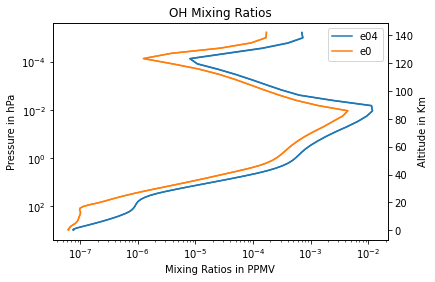

In [16]:
fig, ax1 = plt.subplots()

ax2 = ax1.twinx()

OH_e04_global.plot(y='lev',yscale='log',xscale='log',label='e04',ax=ax1, yincrease=False)

OH_e0_global.plot(y='lev',yscale='log',xscale='log',label='e0',ax=ax1, yincrease=False)

ax2.plot(OH_e04_global.values,Z_e04.values,label='e04')

ax2.plot(OH_e0_global.values,Z_e0.values,label='e0')

ax2.set_xscale('log')

ax2.legend()

ax2.set_xlabel('Mixing Ratios in PPMV')

ax2.set_ylabel('Altitude in Km')

ax1.set_xlabel('Mixing Ratios in PPMV')

ax1.set_ylabel('Pressure in hPa')

plt.title('OH Mixing Ratios')


H2_MR_E0 3.312599543431055
H2_MR_E04 21.931338063361203


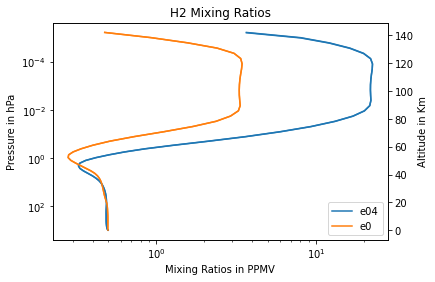

In [17]:
fig, ax1 = plt.subplots()

ax2 = ax1.twinx()

H2_e04_global.plot(y='lev',yscale='log',xscale='log',label='e04',ax=ax1, yincrease=False)

H2_e0_global.plot(y='lev',yscale='log',xscale='log',label='e0',ax=ax1, yincrease=False)

ax2.plot(H2_e04_global.values,Z_e04.values,label='e04')

ax2.plot(H2_e0_global.values,Z_e0.values,label='e0')

ax2.set_xscale('log')

ax2.legend()

ax2.set_xlabel('Mixing Ratios in PPMV')

ax2.set_ylabel('Altitude in Km')

ax1.set_xlabel('Mixing Ratios in PPMV')

ax1.set_ylabel('Pressure in hPa')

plt.title('H2 Mixing Ratios')

print('H2_MR_E0',H2_e0_global.isel(lev=11).values)
print('H2_MR_E04',H2_e04_global.isel(lev=11).values)

H_MR_E0 1.8181909032622545
H_MR_E04 9.376535825351198


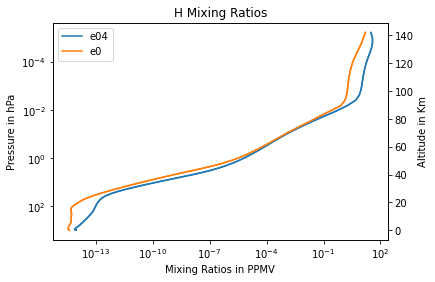

In [18]:
fig, ax1 = plt.subplots()

ax2 = ax1.twinx()

H_e04_global.plot(y='lev',yscale='log',xscale='log',label='e04',ax=ax1, yincrease=False)

H_e0_global.plot(y='lev',yscale='log',xscale='log',label='e0',ax=ax1, yincrease=False)

ax2.plot(H_e04_global.values,Z_e04.values,label='e04')

ax2.plot(H_e0_global.values,Z_e0.values,label='e0')

ax2.set_xscale('log')

ax2.legend()

ax2.set_xlabel('Mixing Ratios in PPMV')

ax2.set_ylabel('Altitude in Km')

ax1.set_xlabel('Mixing Ratios in PPMV')

ax1.set_ylabel('Pressure in hPa')

plt.title('H Mixing Ratios')

print('H_MR_E0',H_e0_global.isel(lev=11).values)
print('H_MR_E04',H_e04_global.isel(lev=11).values)

CH4_MR_E0 0.0016320132574055718
CH4_MR_E04 0.0026921129441477643


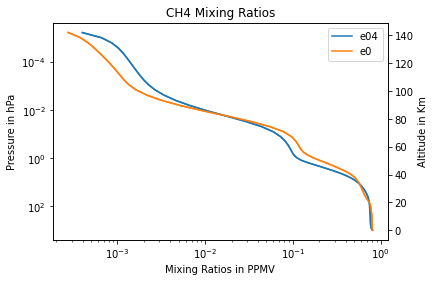

In [19]:
fig, ax1 = plt.subplots()

ax2 = ax1.twinx()

CH4_e04_global.plot(y='lev',yscale='log',xscale='log',label='e04',ax=ax1, yincrease=False)

CH4_e0_global.plot(y='lev',yscale='log',xscale='log',label='e0',ax=ax1, yincrease=False)

ax2.plot(CH4_e04_global.values,Z_e04.values,label='e04')

ax2.plot(CH4_e0_global.values,Z_e0.values,label='e0')

ax2.set_xscale('log')

ax2.legend()

ax2.set_xlabel('Mixing Ratios in PPMV')

ax2.set_ylabel('Altitude in Km')

ax1.set_xlabel('Mixing Ratios in PPMV')

ax1.set_ylabel('Pressure in hPa')

plt.title('CH4 Mixing Ratios')

print('CH4_MR_E0',CH4_e0_global.isel(lev=11).values)
print('CH4_MR_E04',CH4_e04_global.isel(lev=11).values)

Text(0.5, 1.0, 'CH4 Mixing Ratios')

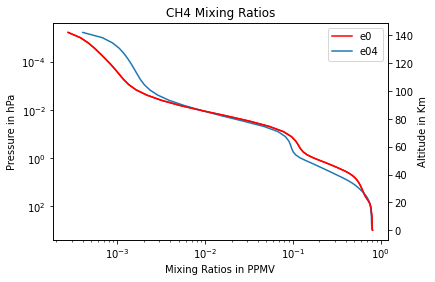

In [20]:
def LatWeightAnyVar_notime(DS):
    try:
        DS = DS.mean(dim='lon')#take longitudinal mean
    except:
        print('')

    DS = gw*DS #multiply by gaussian weights
    try:
        DS = np.sum(DS,axis=2)/gw.sum() #weighted mean
    except:
        DS = np.sum(DS,axis=0)/gw.sum() #weighted mean 
    return DS #return a numpy array that has been modified above

fig, ax1 = plt.subplots()

ax2 = ax1.twinx()

CH4_e0_global.plot(color='red',y='lev',yscale='log',xscale='log',label='e0',ax=ax1, yincrease=False)

CH4_e4_global.plot(y='lev',yscale='log',xscale='log',label='e04',ax=ax1, yincrease=False)

ax2.plot(CH4_e0_global.values,Z_e0.values,color='red')

ax2.set_xscale('log')

ax1.legend()

ax2.set_xlabel('Mixing Ratios in PPMV')

ax2.set_ylabel('Altitude in Km')

ax1.set_xlabel('Mixing Ratios in PPMV')

ax1.set_ylabel('Pressure in hPa')

plt.title('CH4 Mixing Ratios')

# print('CH4_MR_E0',CH4_e0_global.isel(lev=11).values)
# print('CH4_MR_E04',CH4_e04_global.isel(lev=11).values)


Text(0.5, 1.0, 'Seasonal Variability of Ozone for e=0.4 case')

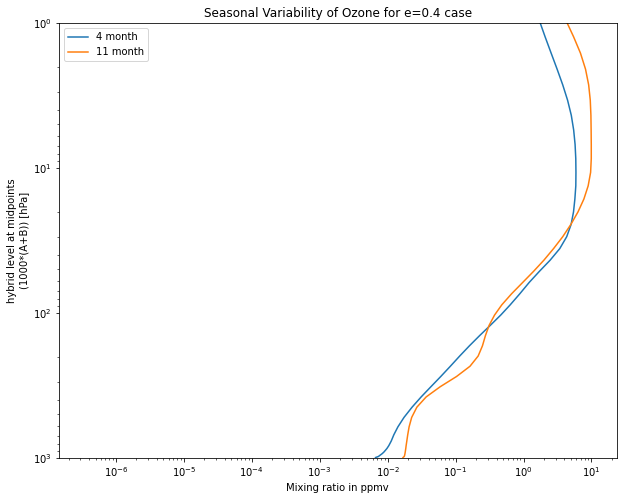

In [21]:
plt.figure(figsize=(10,8))

for i in range(12):
    if i == 3 or i ==10:
        (LatWeightAnyVar(O3_obl0_circ[1].O3.groupby("time.month").mean(dim='time')[i,:,:,:])*10**6).plot(y='lev',yscale='log',xscale='log', yincrease=False,label='%s month' % (i+1))

plt.legend()
plt.ylim(1000,1)
plt.xlabel('Mixing ratio in ppmv')
plt.title('Seasonal Variability of Ozone for e=0.4 case')

In [22]:
ds11 = xr.open_mfdataset('/nobackup/pybl/cesm_sims/archive/b.e21.BWma1850.f19_g17.new_e4_psg.001/atm/hist/CO2_e4_psg_11.nc')

ds4  = xr.open_mfdataset('/nobackup/pybl/cesm_sims/archive/b.e21.BWma1850.f19_g17.new_e4_psg.001/atm/hist/CO2_e4_psg.nc')

ds0  = xr.open_mfdataset('/nobackup/pybl/cesm_sims/archive/b.e21.BWma1850.f19_g17.new_circ_psg.001/atm/hist/CO2_e0_psg.nc')

# ds0  = xr.open_mfdataset('/nobackup/pybl/cesm_sims/archive/b.e21.BWma1850.f19_g17.new_e4_psg.001/atm/hist/psg_e4_04.nc')



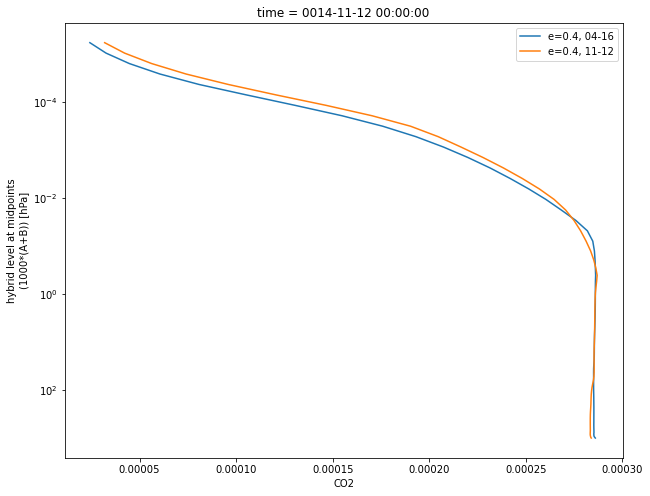

In [23]:
plt.figure(figsize=(10,8))
LatWeightAnyVar(ds4.CO2[0,]).plot(y='lev',yscale='log', yincrease=False,label='e=0.4, 04-16')
LatWeightAnyVar(ds11.CO2[0,]).plot(y='lev',yscale='log', yincrease=False,label='e=0.4, 11-12')
plt.legend()
# LatWeightAnyVar(ds0.CO2).plot(y='lev',yscale='log', yincrease=False,label='circular')

In [24]:
ds4.CO2[0,]

<xarray.DataArray 'CO2' (lev: 70, lat: 96, lon: 144)>
dask.array<getitem, shape=(70, 96, 144), dtype=float32, chunksize=(70, 96, 144), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 -90.0 -88.11 -86.21 -84.32 ... 84.32 86.21 88.11 90.0
  * lon      (lon) float64 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * lev      (lev) float64 5.96e-06 9.827e-06 1.62e-05 ... 957.5 976.3 992.6
    time     object 0014-04-16 00:00:00
Attributes:
    mdims:         1
    units:         mol/mol
    mixing_ratio:  dry
    long_name:     CO2 concentration

Text(0.5, 1.0, 'O3 Mixing Ratios')

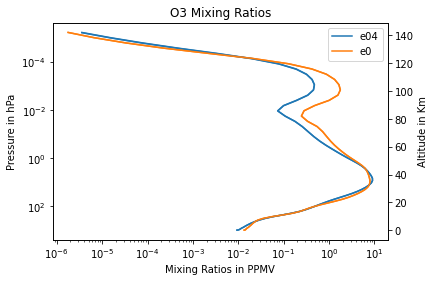

In [25]:
fig, ax1 = plt.subplots()

ax2 = ax1.twinx()

O3_e04_global.plot(y='lev',yscale='log',xscale='log',label='e04',ax=ax1, yincrease=False)

O3_e0_global.plot(y='lev',yscale='log',xscale='log',label='e0',ax=ax1, yincrease=False)

ax2.plot(O3_e04_global.values,Z_e04.values,label='e04')

ax2.plot(O3_e0_global.values,Z_e0.values,label='e0')

ax2.set_xscale('log')

ax2.legend()

ax2.set_xlabel('Mixing Ratios in PPMV')

ax2.set_ylabel('Altitude in Km')

ax1.set_xlabel('Mixing Ratios in PPMV')

ax1.set_ylabel('Pressure in hPa')

plt.title('O3 Mixing Ratios')

Text(0.5, 1.0, 'O3 Mixing Ratios Difference')

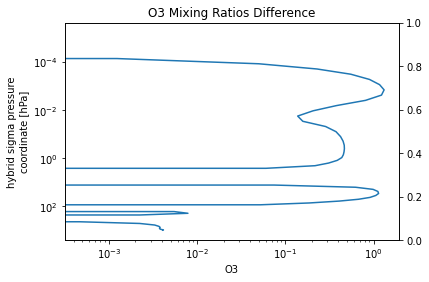

In [26]:
fig, ax1 = plt.subplots()

ax2 = ax1.twinx()

(O3_e0_global-O3_e04_global).plot(y='lev',yscale='log',xscale='log',label='E0-E04',ax=ax1, yincrease=False)


# ax2.plot(O3_e04_global.values,Z_e04.values,label='e04')

# ax2.plot(O3_e0_global.values,Z_e0.values,label='e0')

# ax2.set_xscale('log')

# ax2.legend()

# ax2.set_xlabel('Mixing Ratios in PPMV')

# ax2.set_ylabel('Altitude in Km')

# ax1.set_xlabel('Mixing Ratios in PPMV')

# ax1.set_ylabel('Pressure in hPa')

plt.title('O3 Mixing Ratios Difference')

In [27]:
#%% define latitudinal weighting function

def LatWeightAnyVar_timeframe(DS, time = False):
    try:
        DS = DS.mean(dim='lon')#take longitudinal mean
    except:
        print('')
    DS = gw*DS #multiply by gaussian weights
    try:
        DS = np.sum(DS,axis=2)/gw.sum() #weighted mean
    except:
        DS = np.sum(DS,axis=1)/gw.sum() #weighted mean 
    return DS #return a numpy array that has been modified above

In [28]:
# O3_e04_global_time=LatWeightAnyVar_timeframe(O3_obl0[4].O3)*10**6

# O3_e0_global_time=LatWeightAnyVar_timeframe(O3_obl0[0].O3)*10**6

# diff_O3_time=O3_e04_global_time-O3_e0_global_time

# diff_O3_time.isel(lev=28).plot(label='e04-e01')

# O3_e04_global_time.isel(lev=28).plot(label='e04')

# O3_e0_global_time.isel(lev=28).plot(label='e0')


# plt.legend()

# plt.title('Time Series of O3 Mixing Ratio and Difference')

# plt.ylabel('O3 mixing ratio in ppmv')

In [29]:
# O3_e0_global_time.lev.isel(lev=28)

H2O_MR_E01_100km 0.23233504897917825
H2O_MR_E04_100km 3.386603956775717
H2O_MR_E01_100mb 3.971479979889421
H2O_MR_E04_100mb 326.32895711997674


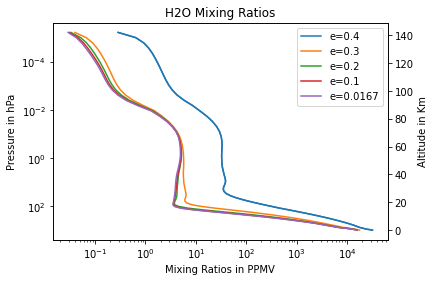

In [30]:
fig, ax1 = plt.subplots()

ax2 = ax1.twinx()

H2O_e04_global.plot(y='lev',yscale='log',xscale='log',label='e=0.4',ax=ax1, yincrease=False)

H2O_e03_global.plot(y='lev',yscale='log',xscale='log',label='e=0.3',ax=ax1, yincrease=False)

H2O_e02_global.plot(y='lev',yscale='log',xscale='log',label='e=0.2',ax=ax1, yincrease=False)

H2O_e01_global.plot(y='lev',yscale='log',xscale='log',label='e=0.1',ax=ax1, yincrease=False)

H2O_e0_global.plot(y='lev',yscale='log',xscale='log',label='e=0.0167',ax=ax1, yincrease=False)


ax2.plot(H2O_e04_global.values,Z_e04.values)

ax2.set_xscale('log')

ax1.legend()

ax2.set_xlabel('Mixing Ratios in PPMV')

ax2.set_ylabel('Altitude in Km')

ax1.set_xlabel('Mixing Ratios in PPMV')

ax1.set_ylabel('Pressure in hPa')

plt.title('H2O Mixing Ratios')


print('H2O_MR_E01_100km',H2O_e01_global.isel(lev=11).values)
print('H2O_MR_E04_100km',H2O_e04_global.isel(lev=11).values)

print('H2O_MR_E01_100mb',H2O_e01_global.isel(lev=-22).values)
print('H2O_MR_E04_100mb',H2O_e04_global.isel(lev=-22).values)

<xarray.DataArray 'H2O' ()>
dask.array<getitem, shape=(), dtype=float64, chunksize=(), chunktype=numpy.ndarray>
Coordinates:
    lev      float64 992.6

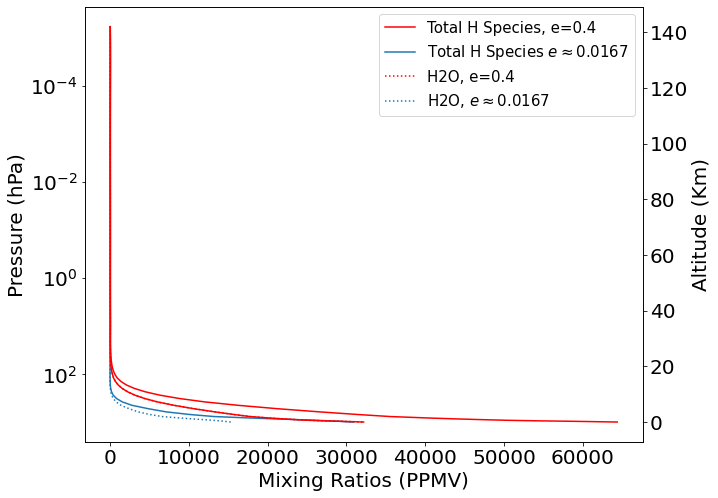

In [31]:
fig, ax1 = plt.subplots(figsize=(10,8))

ax2 = ax1.twinx()

(2*H2O_e04_global+2*H2_e04_global+H_e04_global+4*CH4_e04_global).plot(color='red',y='lev',yscale='log',label='Total H Species, e=0.4',ax=ax1,yincrease=False)

#(H2O_e03_global+H2_e03_global+H_e03_global+CH4_e03_global).plot(y='lev',yscale='log',xscale='log',label='e03',ax=ax1, yincrease=False)

#(H2O_e02_global+H2_e02_global+H_e02_global+CH4_e02_global).plot(y='lev',yscale='log',xscale='log',label='e02',ax=ax1, yincrease=False)

#(H2O_e01_global+H2_e01_global+H_e01_global+CH4_e01_global).plot(y='lev',yscale='log',xscale='log',label='e01',ax=ax1, yincrease=False)

(2*H2O_e0_global+2*H2_e0_global+H_e0_global+4*CH4_e0_global).plot(y='lev',yscale='log',label=r'Total H Species $e \approx %0.004f$'%0.0167,ax=ax1,yincrease=False)


(H2O_e04_global).plot(linestyle='dotted',color='r',y='lev',yscale='log',label='H2O, e=0.4',ax=ax1,yincrease=False)

(H2O_e0_global).plot(linestyle='dotted',color='#1f77b4',y='lev',yscale='log',label=r'H2O, $e \approx %0.004f$'%0.0167,ax=ax1,yincrease=False)

ax2.plot((H2O_e04_global+H2_e04_global+H_e04_global+CH4_e04_global),Z_e04.values,color='red')

# ax2.set_xscale('log')

ax1.legend(fontsize=15)

ax2.set_xlabel('Mixing Ratios (PPMV)',fontsize=20)

ax2.set_ylabel('Altitude (Km)',fontsize=20)

ax1.set_xlabel('Mixing Ratios (PPMV)',fontsize=20)

ax1.set_ylabel('Pressure (hPa)',fontsize=20)

ax1.tick_params(labelsize=20)
ax2.tick_params(labelsize=20)


H2O_e0_global[-1]

In [32]:
H2O_e4_global_last5yr      =LatWeightAnyVar(H2O_obl0_circ[1].H2O[96:156,:,:,:])*10**6

H2O_circ_global_last5yr    =LatWeightAnyVar(H2O_obl0_circ[0].H2O[96:156,:,:,:])*10**6

H2_e4_global_last5yr       =LatWeightAnyVar(H2_obl0_circ[1].H2[96:156,:,:,:])*10**6

H2_circ_global_last5yr     =LatWeightAnyVar(H2_obl0_circ[0].H2[96:156,:,:,:])*10**6

H_e4_global_last5yr        =LatWeightAnyVar(H_obl0_circ[1].H[96:156,:,:,:])*10**6

H_circ_global_last5yr      =LatWeightAnyVar(H_obl0_circ[0].H[96:156,:,:,:])*10**6

CH4_e4_global_last5yr      =LatWeightAnyVar(CH4_obl0_circ[1].CH4[96:156,:,:,:])*10**6

CH4_circ_global_last5yr    =LatWeightAnyVar(CH4_obl0_circ[0].CH4[96:156,:,:,:])*10**6


In [33]:
OH_e4_global_last5yr      =LatWeightAnyVar(OH_obl0_circ[1].OH[96:156,:,:,:])*10**6

OH_circ_global_last5yr    =LatWeightAnyVar(OH_obl0_circ[0].OH[96:156,:,:,:])*10**6

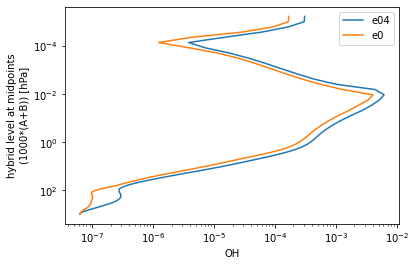

In [34]:


OH_e4_global_last5yr .plot(y='lev',yscale='log',xscale='log',label='e04',yincrease=False)

OH_circ_global_last5yr.plot(y='lev',yscale='log',xscale='log',label='e0',yincrease=False)

plt.legend()

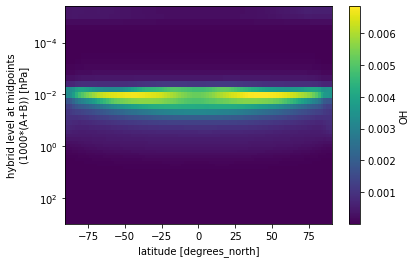

In [35]:
(OH_obl0_circ[1].OH[96:156,:,:,:]*10**6).mean(dim='time').mean(dim='lon').plot(yscale='log',yincrease=False)

this is the last yr H2O MR


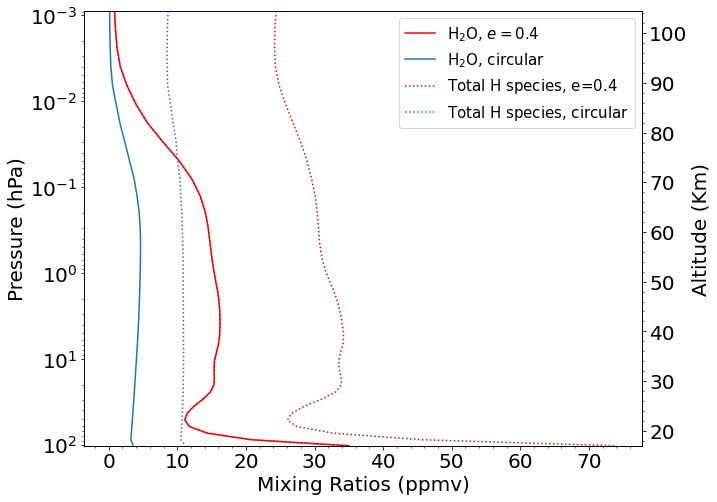

In [105]:
H2O_e4_global_last5yr_strato  =H2O_e4_global_last5yr.where((H2O_e4_global_last5yr.lev > Z_e04.lev[11-2]) & (H2O_e4_global_last5yr.lev < Z_e04.lev[48+1]))

H2O_circ_global_last5yr_strato=H2O_circ_global_last5yr.where((H2O_circ_global_last5yr.lev >  Z_e04.lev[11-2]) & (H2O_circ_global_last5yr.lev < Z_e04.lev[48+1]))


fig, ax1 = plt.subplots(figsize=(10,8))

ax2 = ax1.twinx()

ax1.set_ylim([Z_e04.lev[48],Z_e04.lev[10]])

ax2.set_ylim([Z_e04.values[48],Z_e04.values[10]])

H_species_tot_circ =(2*H2O_circ_global_last5yr+2*H2_circ_global_last5yr+H_circ_global_last5yr+4*CH4_circ_global_last5yr)
H_species_tot_circ_strato=H_species_tot_circ.where((H_species_tot_circ.lev >  Z_e04.lev[11-2]) & (H_species_tot_circ.lev <  Z_e04.lev[48+1]))

H_species_tot_e4 =(2*H2O_e4_global_last5yr+2*H2_e4_global_last5yr+H_e4_global_last5yr+4*CH4_e4_global_last5yr)
H_species_tot_e4_strato=H_species_tot_e4.where((H_species_tot_e4.lev >  Z_e04.lev[11-2]) & (H_species_tot_e4.lev <  Z_e04.lev[48+1]))

H2O_e4_global_last5yr_strato.plot(linestyle='solid',color='r',y='lev',xscale='linear',yscale='log',label='$\mathregular{H_2O}$, $e=0.4$',ax=ax1,yincrease=False)

H2O_circ_global_last5yr_strato.plot(linestyle='solid',color='#1f77b4',y='lev',xscale='linear',yscale='log',label='$\mathregular{H_2O}$, circular',ax=ax1,yincrease=False)

H_species_tot_e4_strato.plot(linestyle='dotted',color='r',y='lev',yscale='log',xscale='linear',label='Total $\mathregular{H}$ species, e=0.4',ax=ax1,yincrease=False)

H_species_tot_circ_strato.plot(linestyle='dotted',color='#1f77b4',y='lev',yscale='log',xscale='linear',label='Total $\mathregular{H}$ species, circular',ax=ax1,yincrease=False)

ax2.plot(H2O_e4_global_last5yr_strato,Z_e04.values,color='r',linestyle='dotted')

ax2.set_xscale('linear')

ax2.set_xlabel('Mixing Ratios (ppmv)',fontsize=20)

ax2.set_ylabel('Altitude (Km)',fontsize=20)

ax1.set_xlabel('Mixing Ratios (ppmv)',fontsize=20)

ax1.set_ylabel('Pressure (hPa)',fontsize=20)

ax1.tick_params(labelsize=20)
ax2.tick_params(labelsize=20)

# Z_e4=Alt_conversion(LatWeightAnyVar(T_obl0_circ[1].T))

# ax1.set_ylim([Z_e4.lev[48],Z_e4.lev[11]])

# ax2.set_ylim([Z_e4.values[48],Z_e4.values[11]])

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()

ax1.legend(h1+h2, l1+l2,loc='best',fontsize=15,ncol=1)

plt.minorticks_on()

plt.savefig("H_species_split_strato_homo.png",dpi=400,bbox_inches="tight")

print('this is the last yr H2O MR')

In [37]:
print(H_species_tot_e4_strato.values)

[        nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan 24.37771218 24.21207745
 24.17819913 24.2963008  24.85459348 25.79449442 26.86144067 27.96208787
 28.86451493 29.56922781 30.10588553 30.39994806 30.56574539 30.69708491
 30.90127141 31.19325739 31.63414574 32.18740774 32.79725972 33.28691282
 33.64195854 33.90277207 34.11598612 34.23398843 34.12915465 33.77881046
 33.49280028 33.60686829 33.87313319 33.93513993 33.042607   30.96965831
 28.4534544  26.66075931 26.05229068 27.38907604 32.80345403 45.67795672
 74.07869554         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan]


In [38]:
# H2O MR difference at tropopause
print(H2O_e4_global_last5yr.values[-26])
print(H2O_e4_global_last5yr.lev.values[-26])
print(H2O_circ_global_last5yr.values[-23])
print(H2O_circ_global_last5yr.lev.values[-23])

11.09414824479363
51.67749896645546
3.23661171579169
87.82123029232025


In [39]:
# H species MR difference at homopause 

print((2*H2O_e4_global_last5yr+2*H2_e4_global_last5yr+H_e4_global_last5yr+4*CH4_e4_global_last5yr).values[11])
print((2*H2O_circ_global_last5yr+2*H2_circ_global_last5yr+H_circ_global_last5yr+4*CH4_circ_global_last5yr).values[11])

24.21207744888152
8.550172034078555


The O3 MR for e=0.4 at the top atmosphere is 0.01238114270377355
The O3 MR for circular orbit at the top atmosphere is 0.013062382067298036


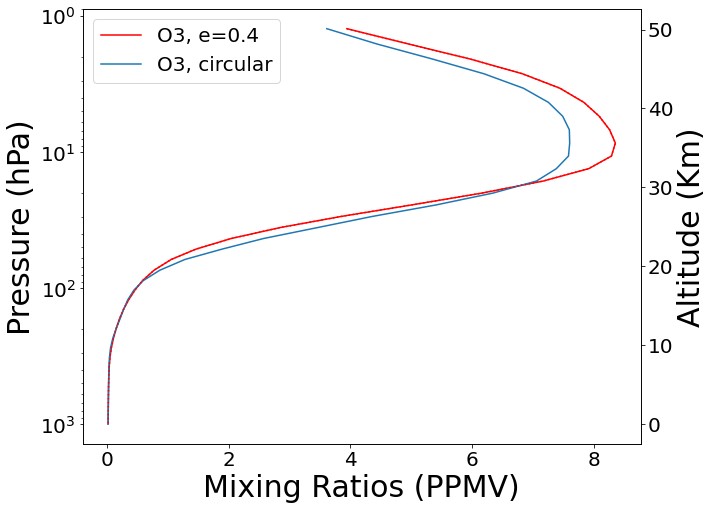

In [40]:
O3_e4_global_last5yr      =LatWeightAnyVar(O3_obl0_circ[1].O3[92:152,:,:,:])*10**6

O3_circ_global_last5yr    =LatWeightAnyVar(O3_obl0_circ[0].O3[92:152,:,:,:])*10**6

fig, ax1 = plt.subplots(figsize=(10,8))

ax2 = ax1.twinx()

O3_e4_global_last5yr.where((O3_e4_global_last5yr.lev > 1) & (O3_e4_global_last5yr.lev < 1000)).plot(linestyle='solid',color='r',y='lev',yscale='log',xscale='linear',label='O3, e=0.4',ax=ax1,yincrease=False)

O3_circ_global_last5yr.where((O3_circ_global_last5yr.lev > 1) & (O3_circ_global_last5yr.lev < 1000)).plot(linestyle='solid',color='#1f77b4',y='lev',yscale='log',xscale='linear',label='O3, circular',ax=ax1,yincrease=False)

ax2.plot(O3_e4_global_last5yr.where((O3_e4_global_last5yr.lev > 1) & (O3_e4_global_last5yr.lev < 1000)),Z_e04.values,color='r',linestyle='dotted')

ax2.set_xscale('linear')

ax1.legend(fontsize=20)

ax2.set_xlabel('Mixing Ratios (PPMV)',fontsize=30)

ax2.set_ylabel('Altitude (Km)',fontsize=30)

ax1.set_xlabel('Mixing Ratios (PPMV)',fontsize=30)

ax1.set_ylabel('Pressure (hPa)',fontsize=30)

ax1.tick_params(labelsize=20)
ax2.tick_params(labelsize=20)

print("The O3 MR for e=0.4 at the top atmosphere is",O3_e4_global_last5yr.values[-1])
print("The O3 MR for circular orbit at the top atmosphere is",O3_circ_global_last5yr.values[-1])



In [41]:
print(np.max(O3_e4_global_last5yr.values))
print(np.max(O3_circ_global_last5yr.values))

print((np.max(O3_e4_global_last5yr.values)-np.max(O3_circ_global_last5yr.values))/np.max(O3_circ_global_last5yr.values))

8.358794914614355
7.607315278273691
0.0987838164781828


[]

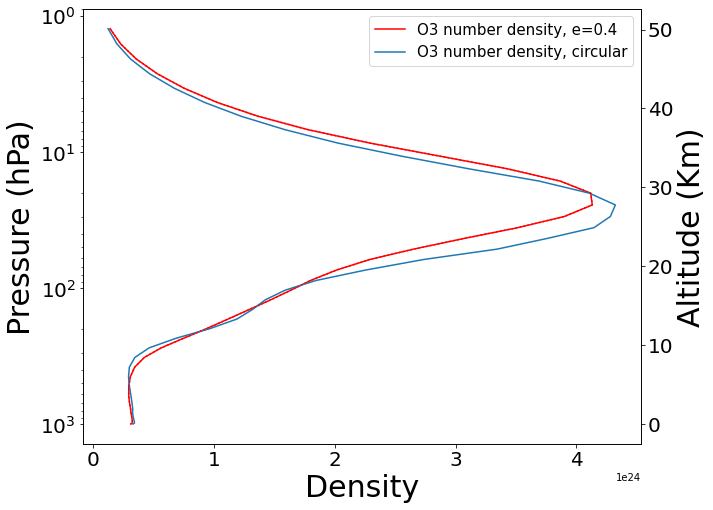

In [42]:
# n = p/kt t is temp at layer, p in pscal

# temperature profile

T_e4_global_last5yr        =LatWeightAnyVar(T_obl0_circ[1].T[92:152,:,:,:])

T_circ_global_last5yr      =LatWeightAnyVar(T_obl0_circ[0].T[92:152,:,:,:])

K        = 1.38 * 10**(-23) # J·K−1

# number density of O3

O3_n_e4   = ((O3_e4_global_last5yr.lev * 100)  /(K*T_e4_global_last5yr))  *O3_e4_global_last5yr

O3_n_circ = ((O3_circ_global_last5yr.lev * 100)/(K*T_circ_global_last5yr))*O3_circ_global_last5yr

# plot

fig, ax1 = plt.subplots(figsize=(10,8))

ax2 = ax1.twinx()

# where((O3_n_e4.lev > 1) & (O3_n_e4.lev < 1000))
# where((O3_n_circ.lev > 1) & (O3_n_circ.lev < 1000))

O3_n_e4.where((O3_n_e4.lev > 1) & (O3_n_e4.lev < 1000)).plot(color='r',y='lev',yscale='log',label='O3 number density, e=0.4',ax=ax1,yincrease=False)

O3_n_circ.where((O3_n_circ.lev > 1) & (O3_n_circ.lev < 1000)).plot(color='#1f77b4',y='lev',yscale='log',label='O3 number density, circular',ax=ax1,yincrease=False)

ax2.plot(O3_n_e4.where((O3_n_e4.lev > 1) & (O3_n_e4.lev < 1000)),Z_e04.values,color='r',linestyle='dotted')

# ax2.set_xscale('log')

# ax1.set_xscale('log')

ax1.legend(fontsize=15)

ax1.set_xlabel('Density',fontsize=30)

ax2.set_ylabel('Altitude (Km)',fontsize=30)

ax1.set_ylabel('Pressure (hPa)',fontsize=30)

ax1.tick_params(labelsize=20)
ax2.tick_params(labelsize=20)

plt.plot()

In [43]:
print('the max ozone number density for e4',np.max(O3_n_e4.values))
print('the max ozone number density for circ',np.max(O3_n_circ.values))
print('the circular case has higher o3 by',np.abs(np.max(O3_n_circ.values)-np.max(O3_n_e4.values))/(np.max(O3_n_e4.values)))

the max ozone number density for e4 4.132774762642419e+24
the max ozone number density for circ 4.324129829053267e+24
the circular case has higher o3 by 0.04630183772427481


T_air 252.99738751072707


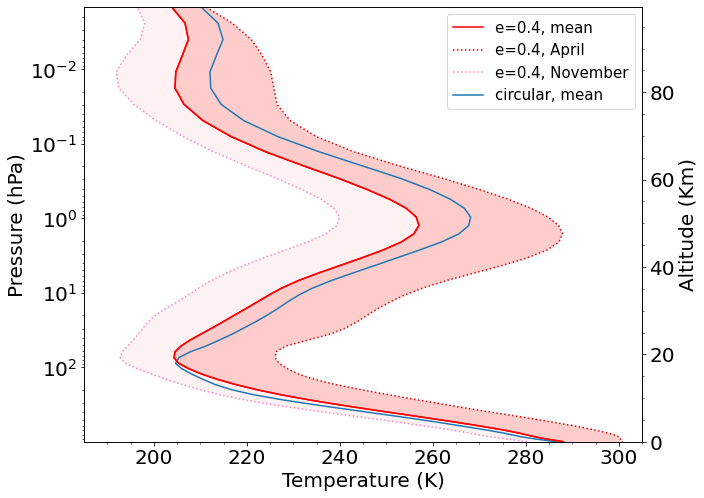

In [44]:
# T_e4_global_lastyr      =LatWeightAnyVar(T_obl0_circ[1].T[108:120,:,:,:])

# T_circ_global_lastyr    =LatWeightAnyVar(T_obl0_circ[0].T[108:120,:,:,:])

def LatWeightAnyVar_notime(DS):
    try:
        DS = DS.mean(dim='lon')#take longitudinal mean
    except:
        print('')

    DS = gw*DS #multiply by gaussian weights
    try:
        DS = np.sum(DS,axis=2)/gw.sum() #weighted mean
    except:
        DS = np.sum(DS,axis=0)/gw.sum() #weighted mean 
    return DS #return a numpy array that has been modified above

Z_e4=Alt_conversion(LatWeightAnyVar(T_obl0_circ[1].T))

fig, ax1 = plt.subplots(figsize=(10,8)) 

ax2 = ax1.twinx()

T_e4_global_last5yr.plot(linestyle='solid',color='r',y='lev',yscale='log',label='e=0.4, mean',ax=ax1,yincrease=False)

e4_APR_T=LatWeightAnyVar_notime(T_obl0_circ[1].T[92:152,:,:,:]).where((T_obl0_circ[1].T['time.month']==4)).mean('time')

e4_NOV_T=LatWeightAnyVar_notime(T_obl0_circ[1].T[92:152,:,:,:]).where((T_obl0_circ[1].T['time.month']==11)).mean('time')

e4_APR_T.plot(linestyle='dotted',color='#E50000',y='lev',yscale='log',label='e=0.4, April',ax=ax1,yincrease=False)

e4_NOV_T.plot(linestyle='dotted',color='#FF81C0',y='lev',yscale='log',label='e=0.4, November',ax=ax1,yincrease=False)

T_circ_global_last5yr.plot(linestyle='solid',color='#1f77b4',y='lev',yscale='log',label='circular, mean',ax=ax1,yincrease=False)

ax1.fill_between(
    np.append(T_e4_global_last5yr.T.values.tolist(), e4_APR_T.T.values.tolist()[::-1]),
    np.append(T_e4_global_last5yr.lev.values.tolist(), e4_APR_T.lev.values.tolist()[::-1]), color='red',alpha=.2, linewidth=0
)

ax1.fill_between(
    np.append(T_e4_global_last5yr.T.values.tolist(), e4_NOV_T.T.values.tolist()[::-1]),
    np.append(T_e4_global_last5yr.lev.values.tolist(), e4_NOV_T.lev.values.tolist()[::-1]), color='pink',alpha=.2, linewidth=0
)

ax1.set_ylim([Z_e4.lev[-1],Z_e4.lev[11]])
ax1.set_xlim([185,305])

ax2.set_ylim([Z_e4.values[-1],Z_e4.values[11]])
ax2.set_xlim([185,305])

ax2.plot(T_e4_global_last5yr,Z_e4.values,color='r',linestyle='solid')

ax1.legend(fontsize=15)

ax2.set_xlabel('T (Kelvin)',fontsize=20)

ax2.set_ylabel('Altitude (Km)',fontsize=20)

ax1.set_xlabel('Temperature (K)',fontsize=20)

ax1.set_ylabel('Pressure (hPa)',fontsize=20)


ax1.tick_params(labelsize=20)
ax2.tick_params(labelsize=20)

plt.minorticks_on()


plt.savefig("T_profile.png",dpi=400,bbox_inches="tight")



In [45]:
e4_APR_T[-1].values-T_e4_global_last5yr[-1].values

12.794159167429939

In [46]:
T_e4_global_last5yr[-1].values-e4_NOV_T[-1].values

7.8304338508878

In [47]:
T_e4_global_last5yr[-1].values

array(288.04897657)

The O3 MR for e=0.4 at the top atmosphere is 0.01238114270377355
The O3 MR for circular orbit at the top atmosphere is 0.013062382067298036


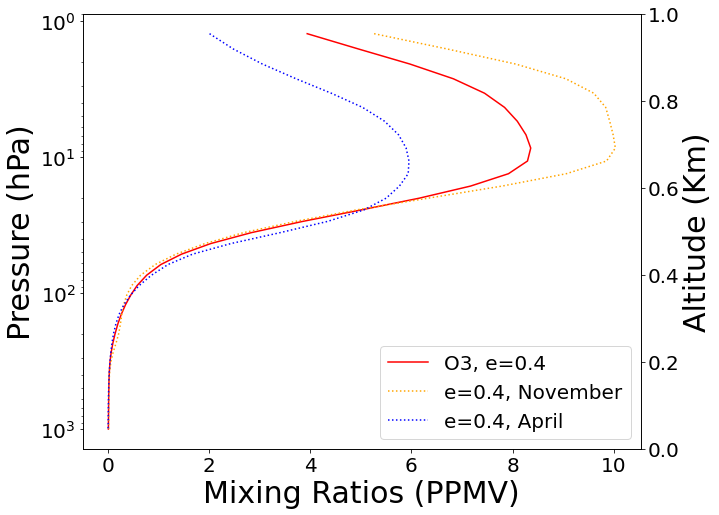

In [48]:


fig, ax1 = plt.subplots(figsize=(10,8))

ax2 = ax1.twinx()

nov_o3_e4= 10**6*LatWeightAnyVar_notime(O3_obl0_circ[1].O3[92:152,:,:,:]).where((O3_obl0_circ[1].O3['time.month']==11)).mean('time')
apr_o3_e4= 10**6*LatWeightAnyVar_notime(O3_obl0_circ[1].O3[92:152,:,:,:]).where((O3_obl0_circ[1].O3['time.month']==4)).mean('time')


O3_e4_global_last5yr.where((O3_e4_global_last5yr.lev > 1) & (O3_e4_global_last5yr.lev < 1000)).plot(linestyle='solid',color='r',y='lev',yscale='log',xscale='linear',label='O3, e=0.4',ax=ax1,yincrease=False)

# O3_circ_global_last5yr.where((O3_circ_global_last5yr.lev > 1) & (O3_circ_global_last5yr.lev < 1000)).plot(linestyle='solid',color='#1f77b4',y='lev',yscale='log',xscale='linear',label='O3, circular',ax=ax1,yincrease=False)

nov_o3_e4.where((nov_o3_e4.lev > 1) & (nov_o3_e4.lev < 1000)).plot(color='orange',linestyle='dotted',y='lev',yscale='log',label='e=0.4, November',ax=ax1,yincrease=False)
apr_o3_e4.where((apr_o3_e4.lev > 1) & (apr_o3_e4.lev < 1000)).plot(color='blue',linestyle='dotted',y='lev',yscale='log',label='e=0.4, April',ax=ax1,yincrease=False)
# ax2.plot(O3_e4_global_last5yr.where((O3_e4_global_last5yr.lev > 1) & (O3_e4_global_last5yr.lev < 1000)),Z_e04.values,color='r',linestyle='dotted')

# ax2.set_xscale('linear')

ax1.legend(fontsize=20)

ax2.set_xlabel('Mixing Ratios (PPMV)',fontsize=30)

ax2.set_ylabel('Altitude (Km)',fontsize=30)

ax1.set_xlabel('Mixing Ratios (PPMV)',fontsize=30)

ax1.set_ylabel('Pressure (hPa)',fontsize=30)

ax1.tick_params(labelsize=20)
ax2.tick_params(labelsize=20)

print("The O3 MR for e=0.4 at the top atmosphere is",O3_e4_global_last5yr.values[-1])
print("The O3 MR for circular orbit at the top atmosphere is",O3_circ_global_last5yr.values[-1])



T_air 252.99738751072707


[]

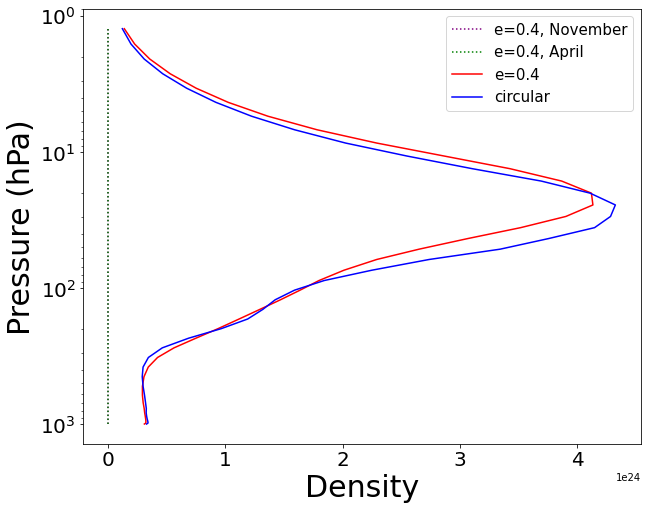

In [49]:
T_e4_global_last5yr        =LatWeightAnyVar(T_obl0_circ[1].T[92:152,:,:,:])

T_circ_global_last5yr      =LatWeightAnyVar(T_obl0_circ[0].T[92:152,:,:,:])

K        = 1.38 * 10**(-23) # J·K−1

# number density of O3

O3_n_e4   = ((O3_e4_global_last5yr.lev * 100)  /(K*T_e4_global_last5yr))  *O3_e4_global_last5yr

O3_n_circ = ((O3_circ_global_last5yr.lev * 100)/(K*T_circ_global_last5yr))*O3_circ_global_last5yr


########################

# use e4_APR_T

apr_o3_e4= LatWeightAnyVar_notime(O3_obl0_circ[1].O3[92:152,:,:,:]).where((O3_obl0_circ[1].O3['time.month']==4)).mean('time')

e4_APR_o3=  ((apr_o3_e4.lev * 100)  /(K*e4_APR_T))  *apr_o3_e4

# use e4_NOV_T


nov_o3_e4= LatWeightAnyVar_notime(O3_obl0_circ[1].O3[92:152,:,:,:]).where((O3_obl0_circ[1].O3['time.month']==11)).mean('time')

e4_NOV_o3=  ((nov_o3_e4.lev * 100)  /(K*e4_NOV_T))  *nov_o3_e4


Z_e4=Alt_conversion(LatWeightAnyVar(T_obl0_circ[1].T))

fig, ax1 = plt.subplots(figsize=(10,8)) 

# ax2 = ax1.twinx()

e4_NOV_o3.where((e4_NOV_o3.lev > 1) & (e4_NOV_o3.lev < 1000)).plot(color='purple',linestyle='dotted',y='lev',yscale='log',label='e=0.4, November',ax=ax1,yincrease=False)

e4_APR_o3.where((e4_APR_o3.lev > 1) & (e4_APR_o3.lev < 1000)).plot(color='green',linestyle='dotted',y='lev',yscale='log',label='e=0.4, April',ax=ax1,yincrease=False)

O3_n_e4.where((O3_n_e4.lev > 1) & (O3_n_e4.lev < 1000)).plot(color='red',y='lev',yscale='log',label='e=0.4',ax=ax1,yincrease=False)

O3_n_circ.where((O3_n_circ.lev > 1) & (O3_n_circ.lev < 1000)).plot(color='blue',y='lev',yscale='log',label='circular',ax=ax1,yincrease=False)

### uncomment the following if you want to see regional difference (different altitude)

# last 5 years, slice lat, regional average 

# e4_NOV_T_1=T_obl0_circ[1].T[92:152,:,:,:][:,:,-35].where((T_obl0_circ[1].T['time.month']==11)).mean('time').mean('lon')

# a_1= 10**6*O3_obl0_circ[1].O3[92:152,:,:,:][:,:,-35].mean(dim='lon')

# # slice month, time average 

# a_2= a_1.where((a_1['time.month']==11)).mean(dim='time')

# a_3=((a_2.lev * 100)  /(K*e4_NOV_T_1))  *a_2

# # slice lev to show

# a_3.where((a_3.lev > 1) & (a_3.lev < 1000)).plot(color='purple',linestyle='dotted',y='lev',yscale='log',label='e=0.4, November, 23.5',ax=ax1,yincrease=False)

####

###


###
# last 5 years, slice lat, regional average 
# e4_NOV_T_3=T_obl0_circ[1].T[92:152,:,:,:][:,:,-20].where((T_obl0_circ[1].T['time.month']==11)).mean('time').mean('lon')


# c_1= 10**6*O3_obl0_circ[1].O3[92:152,:,:,:][:,:,-20].mean(dim='lon')

# # slice month, time average 

# c_2= c_1.where((c_1['time.month']==11)).mean(dim='time')

# c_3=((c_2.lev * 100)  /(K*e4_NOV_T_3))  *c_2

# # slice lev to show

# c_3.where((c_3.lev > 1) & (c_3.lev < 1000)).plot(color='orange',linestyle='dotted',y='lev',yscale='log',label='e=0.4, November, 54',ax=ax1,yincrease=False)

# ####

# # last 5 years, slice lat, regional average 
# e4_NOV_T_3=T_obl0_circ[1].T[92:152,:,:,:][:,:,-10].where((T_obl0_circ[1].T['time.month']==11)).mean('time').mean('lon')


# c_1= 10**6*O3_obl0_circ[1].O3[92:152,:,:,:][:,:,-10].mean(dim='lon')

# # slice month, time average 

# c_2= c_1.where((c_1['time.month']==11)).mean(dim='time')

# c_3=((c_2.lev * 100)  /(K*e4_NOV_T_3))  *c_2

# # slice lev to show

# c_3.where((c_3.lev > 1) & (c_3.lev < 1000)).plot(linestyle='dotted',y='lev',yscale='log',label='e=0.4, November, 73',ax=ax1,yincrease=False)

# ####
# # last 5 years, slice lat, regional average 

# e4_NOV_T_2=T_obl0_circ[1].T[92:152,:,:,:][:,:,-1].where((T_obl0_circ[1].T['time.month']==11)).mean('time').mean('lon')


# b_1= 10**6*O3_obl0_circ[1].O3[92:152,:,:,:][:,:,-1].mean(dim='lon')

# # slice month, time average 

# b_2= b_1.where((b_1['time.month']==11)).mean(dim='time')

# b_3=((b_2.lev * 100)  /(K*e4_NOV_T_2))  *b_2

# # slice lev to show

# b_3.where((b_3.lev > 1) & (b_3.lev < 1000)).plot(color='green',linestyle='dotted',y='lev',yscale='log',label='e=0.4, November, 90',ax=ax1,yincrease=False)

# ####


# ax2.plot(e4_NOV_o3.where((e4_NOV_o3.lev > 1) & (e4_NOV_o3.lev < 1000)),Z_e04.values,color='purple',linestyle='dotted',label='global mean')

ax1.legend(fontsize=15)

ax1.set_xlabel('Density',fontsize=30)

# ax2.set_ylabel('Altitude (Km)',fontsize=30)

ax1.set_ylabel('Pressure (hPa)',fontsize=30)

ax1.tick_params(labelsize=20)
# ax2.tick_params(labelsize=20)

plt.plot()

In [50]:
# e4_NOV_o3.where((e4_NOV_o3.lev > 1) & (e4_NOV_o3.lev < 1000)).plot(color='purple',linestyle='dotted',y='lev',yscale='log',label='e=0.4, November',ax=ax1,yincrease=False)

# e4_APR_o3.where((e4_APR_o3.lev > 1) & (e4_APR_o3.lev < 1000)).plot(color='green',linestyle='dotted',y='lev',yscale='log',label='e=0.4, April',ax=ax1,yincrease=False)

# O3_n_e4.where((O3_n_e4.lev > 1) & (O3_n_e4.lev < 1000)).plot(color='red',y='lev',yscale='log',label='e=0.4',ax=ax1,yincrease=False)

# O3_n_circ.where((O3_n_circ.lev > 1) & (O3_n_circ.lev < 1000)).plot(color='blue',y='lev',yscale='log',label='circular',ax=ax1,yincrease=False)


T_air 252.99738751072707


[]

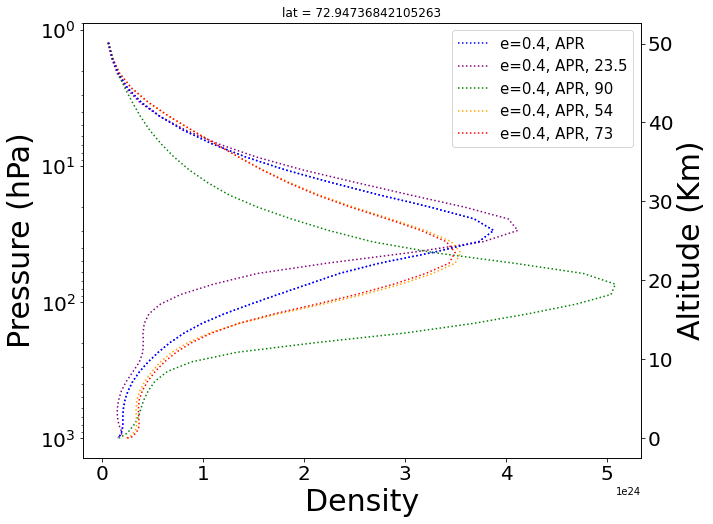

In [51]:
T_e4_global_last5yr        =LatWeightAnyVar(T_obl0_circ[1].T[92:152,:,:,:])

T_circ_global_last5yr      =LatWeightAnyVar(T_obl0_circ[0].T[92:152,:,:,:])

K        = 1.38 * 10**(-23) # J·K−1

# number density of O3

O3_n_e4   = ((O3_e4_global_last5yr.lev * 100)  /(K*T_e4_global_last5yr))  *O3_e4_global_last5yr

O3_n_circ = ((O3_circ_global_last5yr.lev * 100)/(K*T_circ_global_last5yr))*O3_circ_global_last5yr


########################

# use e4_APR_T

apr_o3_e4= 10**6*LatWeightAnyVar_notime(O3_obl0_circ[1].O3[92:152,:,:,:]).where((O3_obl0_circ[1].O3['time.month']==4)).mean('time')

e4_APR_o3=  ((apr_o3_e4.lev * 100)  /(K*e4_APR_T))  *apr_o3_e4

# use e4_NOV_T


nov_o3_e4= 10**6*LatWeightAnyVar_notime(O3_obl0_circ[1].O3[92:152,:,:,:]).where((O3_obl0_circ[1].O3['time.month']==11)).mean('time')

e4_NOV_o3=  ((nov_o3_e4.lev * 100)  /(K*e4_NOV_T))  *nov_o3_e4


Z_e4=Alt_conversion(LatWeightAnyVar(T_obl0_circ[1].T))

fig, ax1 = plt.subplots(figsize=(10,8)) 

ax2 = ax1.twinx()

e4_APR_o3.where((e4_APR_o3.lev > 1) & (e4_APR_o3.lev < 1000)).plot(color='blue',linestyle='dotted',y='lev',yscale='log',label='e=0.4, APR',ax=ax1,yincrease=False)
###
# last 5 years, slice lat, regional average 

e4_APR_T_1=T_obl0_circ[1].T[92:152,:,:,:][:,:,-35].where((T_obl0_circ[1].T['time.month']==4)).mean('time').mean('lon')

a_1= 10**6*O3_obl0_circ[1].O3[92:152,:,:,:][:,:,-35].mean(dim='lon')

# slice month, time average 

a_2= a_1.where((a_1['time.month']==4)).mean(dim='time')

a_3=((a_2.lev * 100)  /(K*e4_APR_T_1))  *a_2

# slice lev to show

a_3.where((a_3.lev > 1) & (a_3.lev < 1000)).plot(color='purple',linestyle='dotted',y='lev',yscale='log',label='e=0.4, APR, 23.5',ax=ax1,yincrease=False)

####

###
# last 5 years, slice lat, regional average 

e4_APR_T_2=T_obl0_circ[1].T[92:152,:,:,:][:,:,-1].where((T_obl0_circ[1].T['time.month']==4)).mean('time').mean('lon')


b_1= 10**6*O3_obl0_circ[1].O3[92:152,:,:,:][:,:,-1].mean(dim='lon')

# slice month, time average 

b_2= b_1.where((b_1['time.month']==4)).mean(dim='time')

b_3=((b_2.lev * 100)  /(K*e4_APR_T_2))  *b_2

# slice lev to show

b_3.where((b_3.lev > 1) & (b_3.lev < 1000)).plot(color='green',linestyle='dotted',y='lev',yscale='log',label='e=0.4, APR, 90',ax=ax1,yincrease=False)

####

###
# last 5 years, slice lat, regional average 
e4_APR_T_3=T_obl0_circ[1].T[92:152,:,:,:][:,:,-20].where((T_obl0_circ[1].T['time.month']==4)).mean('time').mean('lon')


c_1= 10**6*O3_obl0_circ[1].O3[92:152,:,:,:][:,:,-20].mean(dim='lon')

# slice month, time average 

c_2= c_1.where((c_1['time.month']==4)).mean(dim='time')

c_3=((c_2.lev * 100)  /(K*e4_APR_T_3))  *c_2

# slice lev to show

c_3.where((c_3.lev > 1) & (c_3.lev < 1000)).plot(color='orange',linestyle='dotted',y='lev',yscale='log',label='e=0.4, APR, 54',ax=ax1,yincrease=False)

####
###
# last 5 years, slice lat, regional average 

e4_APR_T_4=T_obl0_circ[1].T[92:152,:,:,:][:,:,-10].where((T_obl0_circ[1].T['time.month']==4)).mean('time').mean('lon')


d_1= 10**6*O3_obl0_circ[1].O3[92:152,:,:,:][:,:,-10].mean(dim='lon')

# slice month, time average 

d_2= c_1.where((d_1['time.month']==4)).mean(dim='time')

d_3=((d_2.lev * 100)  /(K*e4_APR_T_4))  *d_2

# slice lev to show

d_3.where((d_3.lev > 1) & (d_3.lev < 1000)).plot(color='red',linestyle='dotted',y='lev',yscale='log',label='e=0.4, APR, 73',ax=ax1,yincrease=False)

####

ax2.plot(e4_APR_o3.where((e4_APR_o3.lev > 1) & (e4_APR_o3.lev < 1000)),Z_e04.values,linestyle='dotted',color='blue')

ax1.legend(fontsize=15)

ax1.set_xlabel('Density',fontsize=30)

ax2.set_ylabel('Altitude (Km)',fontsize=30)

ax1.set_ylabel('Pressure (hPa)',fontsize=30)

ax1.tick_params(labelsize=20)
ax2.tick_params(labelsize=20)

plt.plot()

In [52]:
T_obl0_circ[1].T[92:152,:,:,:][:,:,-10].lat

<xarray.DataArray 'lat' ()>
array(72.94736842)
Coordinates:
    lat      float64 72.95
Attributes:
    long_name:  latitude
    units:      degrees_north

In [53]:
# Z_e4=Alt_conversion(LatWeightAnyVar(T_obl0_circ[1].T))

# fig, ax1 = plt.subplots(figsize=(10,8)) 

# ax2 = ax1.twinx()


# e4_NOV_T=LatWeightAnyVar_notime(T_obl0_circ[1].T[92:152,:,:,:]).where((T_obl0_circ[1].T['time.month']==11)).mean('time')
# e4_NOV_T.plot(linestyle='dotted',color='#FF81C0',y='lev',yscale='log',label='e=0.4, November',ax=ax1,yincrease=False)

# e4_NOV_T_1.plot(linestyle='dotted',y='lev',yscale='log',label='e=0.4, November,23.5',ax=ax1,yincrease=False)
# e4_NOV_T_2.plot(linestyle='dotted',y='lev',yscale='log',label='e=0.4, November,90',ax=ax1,yincrease=False)
# e4_NOV_T_3.plot(linestyle='dotted',y='lev',yscale='log',label='e=0.4, November,54',ax=ax1,yincrease=False)


# ax1.set_ylim([Z_e4.lev[-1],Z_e4.lev[11]])
# ax1.set_xlim([185,305])

# ax2.set_ylim([Z_e4.values[-1],Z_e4.values[11]])
# ax2.set_xlim([185,305])

# ax2.plot(e4_NOV_T,Z_e4.values,color='r',linestyle='solid')

# ax1.legend(fontsize=15)

# ax2.set_xlabel('T (Kelvin)',fontsize=20)

# ax2.set_ylabel('Altitude (Km)',fontsize=20)

# ax1.set_xlabel('Temperature (K)',fontsize=20)

# ax1.set_ylabel('Pressure (hPa)',fontsize=20)


# ax1.tick_params(labelsize=20)
# ax2.tick_params(labelsize=20)

T_air 252.99738751072707


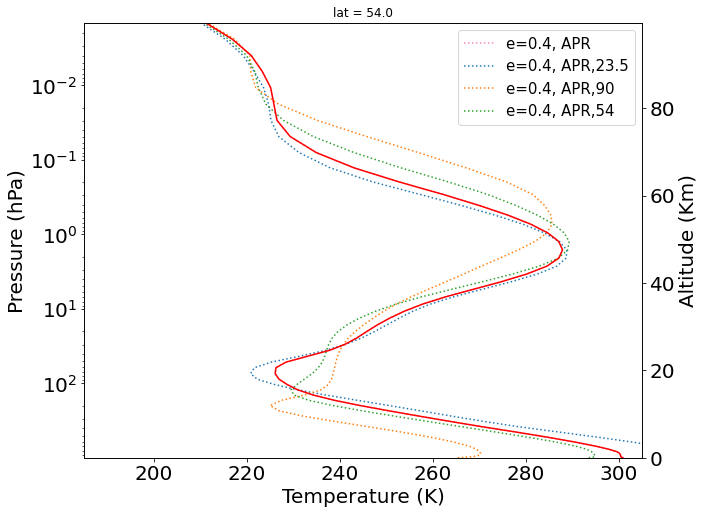

In [54]:
Z_e4=Alt_conversion(LatWeightAnyVar(T_obl0_circ[1].T))

fig, ax1 = plt.subplots(figsize=(10,8)) 

ax2 = ax1.twinx()

e4_APR_T_1=T_obl0_circ[1].T[92:152,:,:,:][:,:,-35].where((T_obl0_circ[1].T['time.month']==4)).mean('time').mean('lon')

e4_APR_T_2=T_obl0_circ[1].T[92:152,:,:,:][:,:,-1].where((T_obl0_circ[1].T['time.month']==4)).mean('time').mean('lon')

e4_APR_T_3=T_obl0_circ[1].T[92:152,:,:,:][:,:,-20].where((T_obl0_circ[1].T['time.month']==4)).mean('time').mean('lon')

e4_APR_T=LatWeightAnyVar_notime(T_obl0_circ[1].T[92:152,:,:,:]).where((T_obl0_circ[1].T['time.month']==4)).mean('time')

e4_APR_T.plot(linestyle='dotted',color='#FF81C0',y='lev',yscale='log',label='e=0.4, APR',ax=ax1,yincrease=False)

e4_APR_T_1.plot(linestyle='dotted',y='lev',yscale='log',label='e=0.4, APR,23.5',ax=ax1,yincrease=False)

e4_APR_T_2.plot(linestyle='dotted',y='lev',yscale='log',label='e=0.4, APR,90',ax=ax1,yincrease=False)

e4_APR_T_3.plot(linestyle='dotted',y='lev',yscale='log',label='e=0.4, APR,54',ax=ax1,yincrease=False)


ax1.set_ylim([Z_e4.lev[-1],Z_e4.lev[11]])
ax1.set_xlim([185,305])

ax2.set_ylim([Z_e4.values[-1],Z_e4.values[11]])
ax2.set_xlim([185,305])

ax2.plot(e4_APR_T,Z_e4.values,color='r',linestyle='solid')

ax1.legend(fontsize=15)

ax2.set_xlabel('T (Kelvin)',fontsize=20)

ax2.set_ylabel('Altitude (Km)',fontsize=20)

ax1.set_xlabel('Temperature (K)',fontsize=20)

ax1.set_ylabel('Pressure (hPa)',fontsize=20)


ax1.tick_params(labelsize=20)
ax2.tick_params(labelsize=20)

(<xarray.DataArray 'lev' ()>
 array(992.55609512)
 Coordinates:
     lev      float64 992.6
 Attributes:
     long_name:      hybrid level at midpoints (1000*(A+B))
     units:          hPa
     positive:       down
     standard_name:  atmosphere_hybrid_sigma_pressure_coordinate
     formula_terms:  a: hyam b: hybm p0: P0 ps: PS,
 <xarray.DataArray 'lev' ()>
 array(0.00145846)
 Coordinates:
     lev      float64 0.001458
 Attributes:
     long_name:      hybrid level at midpoints (1000*(A+B))
     units:          hPa
     positive:       down
     standard_name:  atmosphere_hybrid_sigma_pressure_coordinate
     formula_terms:  a: hyam b: hybm p0: P0 ps: PS)

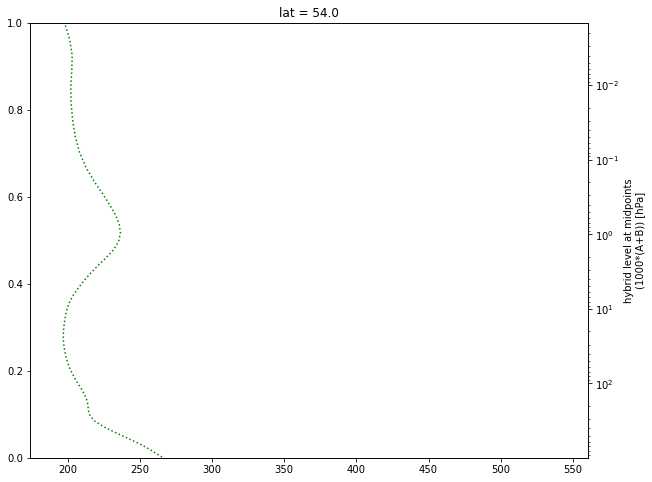

In [55]:
fig, ax1 = plt.subplots(figsize=(10,8)) 

ax2 = ax1.twinx()

T_1= T_obl0_circ[1].T[92:152,:,:,:][:,:,-20].mean(dim='lon')

# slice month, time average 

T_2= T_1.where((T_1['time.month']==11)).mean(dim='time')

# slice lev to show

T_2.plot(color='green',linestyle='dotted',y='lev',yscale='log',label='e=0.4, November, 90',yincrease=False)

plt.ylim([Z_e4.lev[-1],Z_e4.lev[11]])


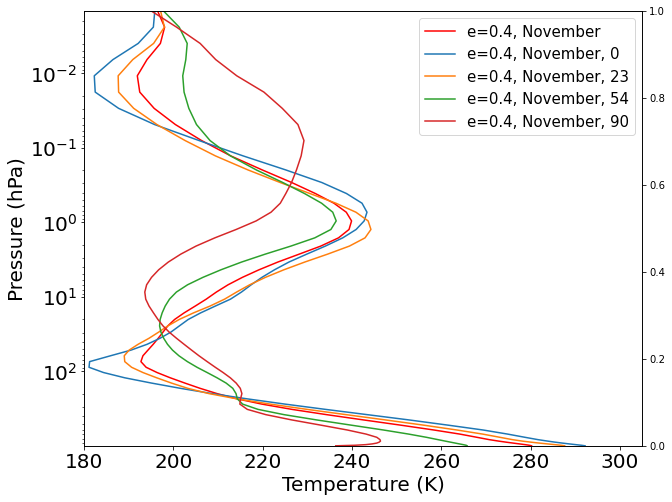

In [56]:
fig, ax1 = plt.subplots(figsize=(10,8)) 

ax2 = ax1.twinx()

e4_NOV_T.plot(color='red',y='lev',yscale='log',label='e=0.4, November',ax=ax1,yincrease=False)

T_2= T_obl0_circ[1].T[92:152,:,:,:][:,:,-20].mean(dim='lon').where((T_1['time.month']==11)).mean(dim='time')


T_5= T_obl0_circ[1].T[92:152,:,:,:][:,:,-48].mean(dim='lon').where((T_1['time.month']==11)).mean(dim='time')

T_5.plot(y='lev',yscale='log',label='e=0.4, November, 0',ax=ax1,yincrease=False)


T_4= T_obl0_circ[1].T[92:152,:,:,:][:,:,-35].mean(dim='lon').where((T_1['time.month']==11)).mean(dim='time')

T_4.plot(y='lev',yscale='log',label='e=0.4, November, 23',ax=ax1,yincrease=False)


T_2.plot(y='lev',yscale='log',label='e=0.4, November, 54',ax=ax1,yincrease=False)


T_3= T_obl0_circ[1].T[92:152,:,:,:][:,:,-1].mean(dim='lon').where((T_1['time.month']==11)).mean(dim='time')

T_3.plot(y='lev',yscale='log',label='e=0.4, November, 90',ax=ax1,yincrease=False)



# ax2.plot(T_e4_global_last5yr,Z_e4.values,color='r',linestyle='solid')

ax1.set_ylim([Z_e4.lev[-1],Z_e4.lev[11]])
ax1.legend(fontsize=15)
ax1.set_xlim([180,305])
ax1.set_xlabel('Temperature (K)',fontsize=20)
ax1.set_ylabel('Pressure (hPa)',fontsize=20)
ax1.tick_params(labelsize=20)

# ax2.set_ylim([Z_e4.values[-1],Z_e4.values[11]])
# ax2.set_xlim([185,305])
# ax2.set_xlabel('T (Kelvin)',fontsize=20)
# ax2.set_ylabel('Altitude (Km)',fontsize=20)
# ax2.tick_params(labelsize=20)

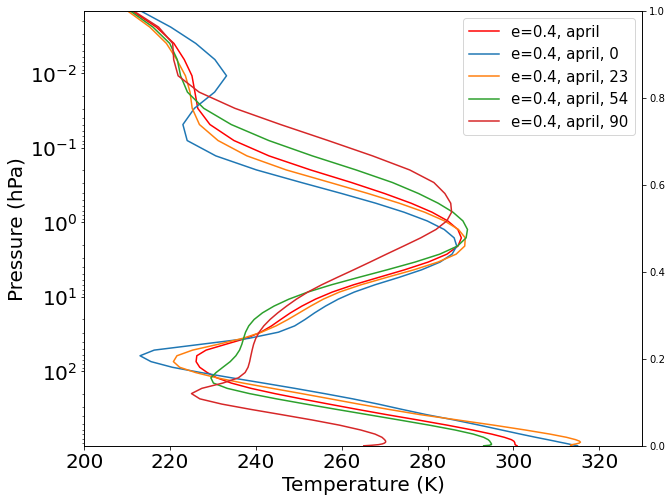

In [57]:
fig, ax1 = plt.subplots(figsize=(10,8)) 

ax2 = ax1.twinx()

e4_APR_T.plot(color='red',y='lev',yscale='log',label='e=0.4, april',ax=ax1,yincrease=False)

T_2= T_obl0_circ[1].T[92:152,:,:,:][:,:,-20].mean(dim='lon').where((T_1['time.month']==4)).mean(dim='time')


T_5= T_obl0_circ[1].T[92:152,:,:,:][:,:,-48].mean(dim='lon').where((T_1['time.month']==4)).mean(dim='time')

T_5.plot(y='lev',yscale='log',label='e=0.4, april, 0',ax=ax1,yincrease=False)


T_4= T_obl0_circ[1].T[92:152,:,:,:][:,:,-35].mean(dim='lon').where((T_1['time.month']==4)).mean(dim='time')

T_4.plot(y='lev',yscale='log',label='e=0.4, april, 23',ax=ax1,yincrease=False)


T_2.plot(y='lev',yscale='log',label='e=0.4, april, 54',ax=ax1,yincrease=False)


T_3= T_obl0_circ[1].T[92:152,:,:,:][:,:,-1].mean(dim='lon').where((T_1['time.month']==4)).mean(dim='time')

T_3.plot(y='lev',yscale='log',label='e=0.4, april, 90',ax=ax1,yincrease=False)



# ax2.plot(T_e4_global_last5yr,Z_e4.values,color='r',linestyle='solid')

ax1.set_ylim([Z_e4.lev[-1],Z_e4.lev[11]])
ax1.legend(fontsize=15)
ax1.set_xlim([200,330])
ax1.set_xlabel('Temperature (K)',fontsize=20)
ax1.set_ylabel('Pressure (hPa)',fontsize=20)
ax1.tick_params(labelsize=20)

# ax2.set_ylim([Z_e4.values[-1],Z_e4.values[11]])
# ax2.set_xlim([185,305])
# ax2.set_xlabel('T (Kelvin)',fontsize=20)
# ax2.set_ylabel('Altitude (Km)',fontsize=20)
# ax2.tick_params(labelsize=20)

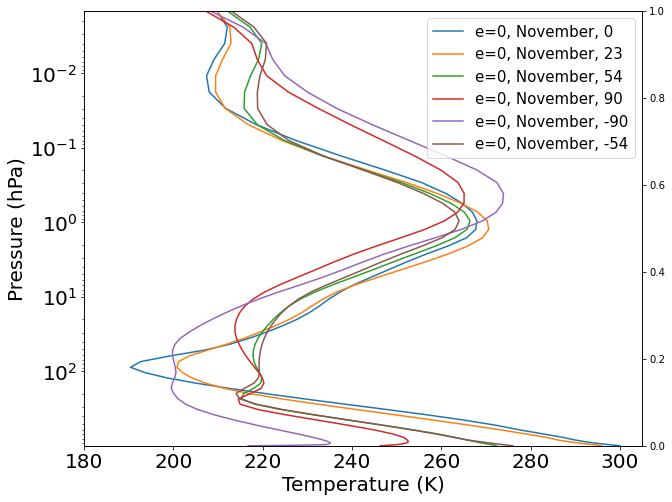

In [58]:
fig, ax1 = plt.subplots(figsize=(10,8)) 

ax2 = ax1.twinx()

T_2= T_obl0_circ[0].T[92:152,:,:,:][:,:,-20].mean(dim='lon').where((T_1['time.month']==11)).mean(dim='time')


T_5= T_obl0_circ[0].T[92:152,:,:,:][:,:,-48].mean(dim='lon').where((T_1['time.month']==11)).mean(dim='time')

T_5.plot(y='lev',yscale='log',label='e=0, November, 0',ax=ax1,yincrease=False)


T_4= T_obl0_circ[0].T[92:152,:,:,:][:,:,-35].mean(dim='lon').where((T_1['time.month']==11)).mean(dim='time')

T_4.plot(y='lev',yscale='log',label='e=0, November, 23',ax=ax1,yincrease=False)


T_2.plot(y='lev',yscale='log',label='e=0, November, 54',ax=ax1,yincrease=False)


T_3= T_obl0_circ[0].T[92:152,:,:,:][:,:,-1].mean(dim='lon').where((T_1['time.month']==11)).mean(dim='time')

T_3.plot(y='lev',yscale='log',label='e=0, November, 90',ax=ax1,yincrease=False)


T_6= T_obl0_circ[0].T[92:152,:,:,:][:,:,-96].mean(dim='lon').where((T_1['time.month']==11)).mean(dim='time')

T_6.plot(y='lev',yscale='log',label='e=0, November, -90',ax=ax1,yincrease=False)

T_7= T_obl0_circ[0].T[92:152,:,:,:][:,:,-77].mean(dim='lon').where((T_1['time.month']==11)).mean(dim='time')

T_7.plot(y='lev',yscale='log',label='e=0, November, -54',ax=ax1,yincrease=False)

# ax2.plot(T_e4_global_last5yr,Z_e4.values,color='r',linestyle='solid')

ax1.set_ylim([Z_e4.lev[-1],Z_e4.lev[11]])
ax1.legend(fontsize=15)
ax1.set_xlim([180,305])
ax1.set_xlabel('Temperature (K)',fontsize=20)
ax1.set_ylabel('Pressure (hPa)',fontsize=20)
ax1.tick_params(labelsize=20)

# ax2.set_ylim([Z_e4.values[-1],Z_e4.values[11]])
# ax2.set_xlim([185,305])
# ax2.set_xlabel('T (Kelvin)',fontsize=20)
# ax2.set_ylabel('Altitude (Km)',fontsize=20)
# ax2.tick_params(labelsize=20)

In [59]:
 T_obl0_circ[1].T[92:152,:,:,:][:,:,-77].lat

<xarray.DataArray 'lat' ()>
array(-54.)
Coordinates:
    lat      float64 -54.0
Attributes:
    long_name:  latitude
    units:      degrees_north

In [60]:
e4_NOV_o3_zonal   = 10**6*(O3_obl0_circ[1].O3[:,-44:-1,:,:].isel(time=slice(92,152)).where((O3_obl0_circ[1].O3['time.month']==11)).mean('time').mean(dim='lon'))

e4_APR_o3_zonal   = 10**6*(O3_obl0_circ[1].O3[:,-44:-1,:,:].isel(time=slice(92,152)).where((O3_obl0_circ[1].O3['time.month']==4)).mean('time').mean(dim='lon'))

O3_n_e4_zonal     = 10**6*(O3_obl0_circ[1].O3[:,-44:-1,:,:].isel(time=slice(92,152)).mean('time').mean(dim='lon'))


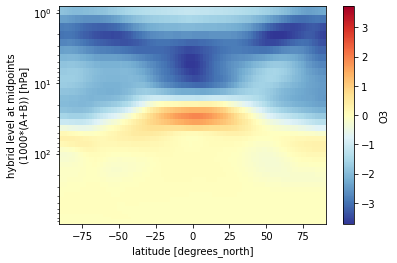

In [61]:
(e4_APR_o3_zonal-O3_n_e4_zonal).plot(y='lev',yscale='log',yincrease=False,cmap='RdYlBu_r')

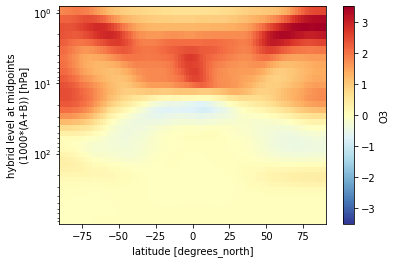

In [62]:
(e4_NOV_o3_zonal-O3_n_e4_zonal).plot(y='lev',yscale='log',yincrease=False,cmap='RdYlBu_r')

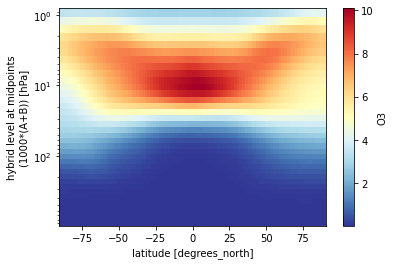

In [63]:
O3_n_e4_zonal.plot(y='lev',yscale='log',yincrease=False,cmap='RdYlBu_r')

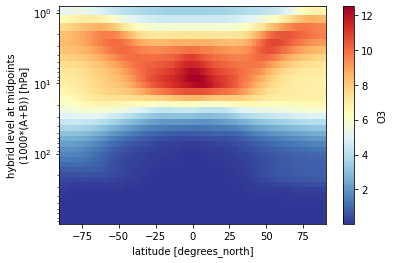

In [64]:
(e4_NOV_o3_zonal).plot(y='lev',yscale='log',yincrease=False,cmap='RdYlBu_r')

In [65]:
e4_NOV_o3_zonal   = 10**6*(O3_obl0_circ[1].O3[:,-25:-15,:,:].isel(time=slice(92,152)).where((O3_obl0_circ[1].O3['time.month']==11)).mean('time').mean(dim='lon'))

e4_APR_o3_zonal   = 10**6*(O3_obl0_circ[1].O3[:,-25:-15,:,:].isel(time=slice(92,152)).where((O3_obl0_circ[1].O3['time.month']==4)).mean('time').mean(dim='lon'))

O3_n_e4_zonal     = 10**6*(O3_obl0_circ[1].O3[:,-25:-15,:,:].isel(time=slice(92,152)).mean('time').mean(dim='lon'))


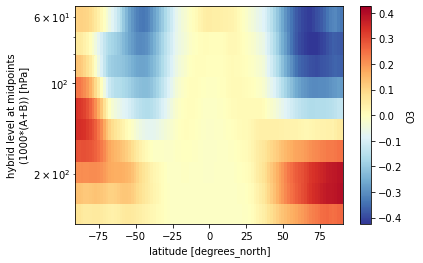

In [66]:
(e4_NOV_o3_zonal-O3_n_e4_zonal).plot(y='lev',yscale='log',yincrease=False,cmap='RdYlBu_r')

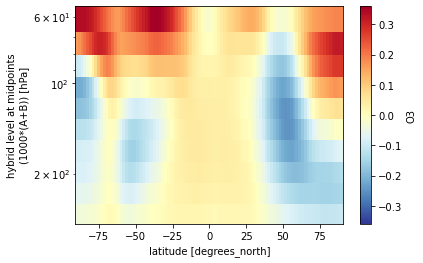

In [67]:
(e4_APR_o3_zonal-O3_n_e4_zonal).plot(y='lev',yscale='log',yincrease=False,cmap='RdYlBu_r')

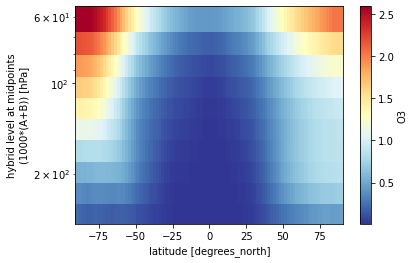

In [68]:
(e4_NOV_o3_zonal).plot(y='lev',yscale='log',yincrease=False,cmap='RdYlBu_r')

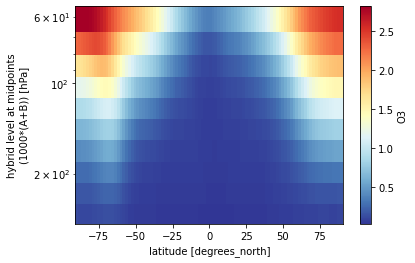

In [69]:
(e4_APR_o3_zonal).plot(y='lev',yscale='log',yincrease=False,cmap='RdYlBu_r')

In [70]:
apr_o3_e4= LatWeightAnyVar_notime(O3_obl0_circ[1].O3[92:152,:,:,:].where((O3_obl0_circ[1].O3['time.month']==4))).mean('time')

e4_APR_o3=  ((apr_o3_e4.lev * 100)  /(K*e4_APR_T))  *apr_o3_e4

# use e4_NOV_T


nov_o3_e4= LatWeightAnyVar_notime(O3_obl0_circ[1].O3[92:152,:,:,:].where((O3_obl0_circ[1].O3['time.month']==11))).mean('time')

e4_NOV_o3=  ((nov_o3_e4.lev * 100)  /(K*e4_NOV_T))  *nov_o3_e4


In [71]:
10**6*LatWeightAnyVar_notime(O3_obl0_circ[1].O3[92:152,:,:,:]).where((O3_obl0_circ[1].O3['time.month']==11)).mean(dim='time').values
                             
                             

array([4.07122944e-06, 1.69547060e-05, 9.03465818e-05, 6.14882049e-04,
       5.07115048e-03, 3.43712135e-02, 1.39382477e-01, 3.48931716e-01,
       6.12797012e-01, 8.44362094e-01, 9.90105854e-01, 9.69989939e-01,
       6.97033677e-01, 3.46884938e-01, 1.58816327e-01, 1.07084008e-01,
       1.56861998e-01, 2.64606968e-01, 3.82234442e-01, 5.12683607e-01,
       7.00496227e-01, 9.75393896e-01, 1.34715221e+00, 1.81124327e+00,
       2.36566220e+00, 3.07010916e+00, 4.01719562e+00, 5.26357564e+00,
       6.71066818e+00, 8.06013616e+00, 9.05294574e+00, 9.60510598e+00,
       9.84016448e+00, 9.91920396e+00, 9.98697080e+00, 1.00310260e+01,
       9.85676693e+00, 9.06252003e+00, 7.79271642e+00, 6.33206061e+00,
       4.91047012e+00, 3.70365597e+00, 2.68347414e+00, 1.92283585e+00,
       1.34739410e+00, 9.39004348e-01, 6.49184644e-01, 4.73586160e-01,
       3.74642057e-01, 3.14045744e-01, 2.77743716e-01, 2.50753640e-01,
       2.16039684e-01, 1.63390149e-01, 1.03268069e-01, 5.92068719e-02,
      

In [72]:
O3_e4_global_last5yr.values

array([3.53341788e-06, 1.33328946e-05, 6.55892340e-05, 4.15104872e-04,
       3.30087342e-03, 2.42575613e-02, 1.16256221e-01, 3.32929452e-01,
       6.15031945e-01, 8.54667205e-01, 1.00344034e+00, 1.00014861e+00,
       7.72886114e-01, 4.42344687e-01, 2.27849295e-01, 1.40831833e-01,
       1.53081044e-01, 2.48423672e-01, 3.69079246e-01, 4.96911654e-01,
       6.53071365e-01, 8.61570535e-01, 1.13746957e+00, 1.48203035e+00,
       1.89168479e+00, 2.40275356e+00, 3.07358566e+00, 3.94146378e+00,
       4.95667245e+00, 5.97145399e+00, 6.83019617e+00, 7.44650344e+00,
       7.84114056e+00, 8.09324433e+00, 8.26450083e+00, 8.35879491e+00,
       8.29489999e+00, 7.91937647e+00, 7.16915407e+00, 6.15747671e+00,
       5.00442630e+00, 3.84804035e+00, 2.83716455e+00, 2.03481358e+00,
       1.45705970e+00, 1.05070674e+00, 7.68756840e-01, 5.80024727e-01,
       4.53395630e-01, 3.50555433e-01, 2.66529778e-01, 1.99172930e-01,
       1.45202194e-01, 1.00800497e-01, 6.61436628e-02, 4.34652992e-02,
      

In [73]:
# plt.fill_between(T_e4_global_last5yr.T.values.tolist(), T_e4_global_last5yr.lev.values.tolist(), e4_APR_T.lev.values.tolist(), color='grey')
# plt.gca().invert_yaxis()
# plt.yscale('log')
# plt.ylim(10**(3),1)
# plt.show()
# plt.figure(figsize=(10,8)) 
# plt.plot(T_e4_global_last5yr.T.values.tolist(),T_e4_global_last5yr.lev.values.tolist(),color='b')
# plt.plot(e4_APR_T.T.values.tolist(),e4_APR_T.lev.values.tolist(),color='r')
# plt.fill_between(
#     np.append(T_e4_global_last5yr.T.values.tolist(), e4_APR_T.T.values.tolist()[::-1]),
#     np.append(T_e4_global_last5yr.lev.values.tolist(), e4_APR_T.lev.values.tolist()[::-1]), color='purple',alpha=.3, linewidth=0
# )
# plt.gca().invert_yaxis()
# plt.yscale('log')
# plt.ylim([Z_e4.lev[-1],Z_e4.lev[11]])
# plt.xlim([185,305])
# plt.show()

In [74]:
Z_e4.lev[-1]

<xarray.DataArray 'lev' ()>
array(992.55609512)
Coordinates:
    lev      float64 992.6
Attributes:
    long_name:      hybrid level at midpoints (1000*(A+B))
    units:          hPa
    positive:       down
    standard_name:  atmosphere_hybrid_sigma_pressure_coordinate
    formula_terms:  a: hyam b: hybm p0: P0 ps: PS

In [75]:
T_e4_global_last5yr.lev.values.tolist()

[5.960300031304655e-06,
 9.826900182474674e-06,
 1.6201850527863826e-05,
 2.671225107775399e-05,
 4.404100018007284e-05,
 7.261274781455995e-05,
 0.00011971900093499244,
 0.00019738000389679655,
 0.0003254225049431625,
 0.0005365325108641628,
 0.0008846024854847201,
 0.001458457461467333,
 0.0024045749569268082,
 0.003978249878855422,
 0.006556825610459782,
 0.010813825610966887,
 0.01789799989637686,
 0.029557750167441554,
 0.04873074976785574,
 0.07991075108293444,
 0.12827324826503173,
 0.19811999663943425,
 0.29202500445535406,
 0.41016750037670135,
 0.5534699885174632,
 0.7304799801204354,
 0.9559475001879036,
 1.2447949848137796,
 1.6128499992191792,
 2.0793249714188278,
 2.6674249675124884,
 3.4048750530928373,
 4.324574954807758,
 5.465399939566851,
 6.872850004583597,
 8.59972508624196,
 10.70705009624362,
 13.264750130474567,
 16.35175058618188,
 20.056750625371933,
 24.47899989783764,
 29.7279991209507,
 35.92325001955032,
 43.1937500834465,
 51.67749896645546,
 61.520498245

In [76]:
# # The function is used to latitudinally average variables, taking consideration of Earth's curvation factor
# # as a guassian weight.

# File_h0 = "/nobackup/pybl/cesm2/archive/b.e21.BWma1850.f19_g17.e0_obl0.001/atm/hist/b.e21.BWma1850.f19_g17.e0_obl0.001.cam.h0.0001-03.nc" #file name

# DataSet_h0 = xr.open_dataset(File_h0,decode_times=False) #open the file and decode time as false

# gw = DataSet_h0.gw.values

# Pressure = DataSet_h0.lev.values

# gw = DataSet_h0.gw.values


# def LatWeightAnyVar_lat(DS,lat_low,lat_high): #Latitudinal weighting function for any latitudinal bands
    
#     DS_lat=[]

#     DS_gw=[]
    
#     global count
    
#     count = 0
    
#     DS = DS.mean(dim='lon') #make zonal mean

#     DS = DS.mean(dim='time') #take time mean
        
#     for i in range(len(DS.lat)): #make regional mean
        
#         if DS.lat[i] >= lat_low and DS.lat[i] <= lat_high :
            
#             DS_lat.append(DS[i])  # extract TS for certain lattitude
            
#             count +=1 
            
#     for i in range(len(DS_lat)): 
        
#         DS_gw.append(gw[i]*DS_lat[i]) #multiply by gaussian weights
    
#     DS_gw_final = np.sum(DS_gw)/gw[:count].sum()

#     return DS_gw_final #return a numpy array that has been modified above

In [77]:
stratopause_T_e0=np.max((T_circ_global_last5yr.T.where(T_circ_global_last5yr.lev<100).where(T_circ_global_last5yr.lev>0.01))).values
stratopause_T_e4=np.max((T_e4_global_last5yr.T.where(T_e4_global_last5yr.lev<100).where(T_e4_global_last5yr.lev>0.01))).values


print(stratopause_T_e0)
print(stratopause_T_e4)
print(stratopause_T_e0-stratopause_T_e4)


268.08706919724716
256.97875405230235
11.108315144944811


In [78]:
Lower_atm_mean_T_e4_april=LatWeightAnyVar_notime(T_obl0_circ[1].T[92:152,:,:,:]).where((T_obl0_circ[1].T['time.month']==4)).mean('time').where(T_circ_global_last5yr.lev>1).values

Lower_atm_mean_T_e4_nov  =LatWeightAnyVar_notime(T_obl0_circ[1].T[92:152,:,:,:]).where((T_obl0_circ[1].T['time.month']==11)).mean('time').where(T_circ_global_last5yr.lev>1).values


print(np.nanmean(Lower_atm_mean_T_e4_april))
print(np.nanmean(Lower_atm_mean_T_e4_nov))


265.55257562947946
227.85230171813794


In [79]:
LatWeightAnyVar_notime(T_obl0_circ[1].T[92:152,:,:,:]).where((T_obl0_circ[1].T['time.month']==11)).mean('time')[-1].values

array(280.21854272)

In [80]:
LatWeightAnyVar_notime(T_obl0_circ[1].T[92:152,:,:,:]).where((T_obl0_circ[1].T['time.month']==10)).mean('time')[-1].values

array(281.00879013)

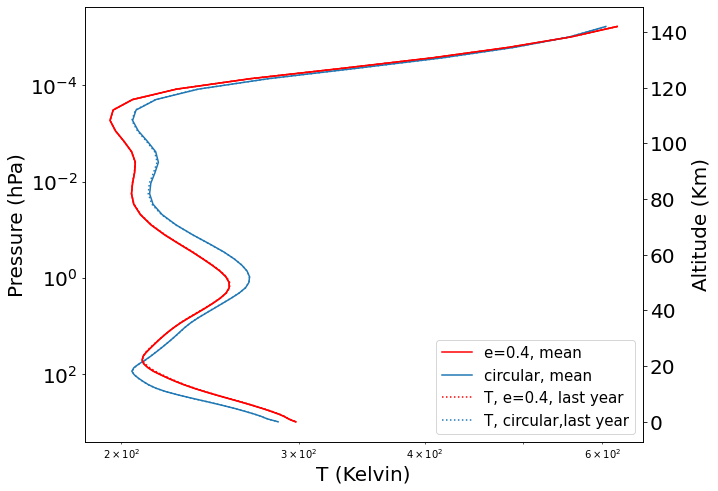

In [81]:
T_e04_global_lastyr      =LatWeightAnyVar(T_obl0[4].T[-13:-1,:,:,:])

T_e0_global_lastyr       =LatWeightAnyVar(T_obl0[0].T[-13:-1,:,:,:])

fig, ax1 = plt.subplots(figsize=(10,8))

ax2 = ax1.twinx()

T_e04_global.plot(linestyle='solid',color='r',y='lev',yscale='log',label='e=0.4, mean',ax=ax1,yincrease=False)

T_e0_global.plot(linestyle='solid',color='#1f77b4',y='lev',yscale='log',label='circular, mean',ax=ax1,yincrease=False)

T_e04_global_lastyr.plot(linestyle='dotted',color='r',y='lev',yscale='log',label='T, e=0.4, last year',ax=ax1,yincrease=False)

T_e0_global_lastyr.plot(linestyle='dotted',color='#1f77b4',y='lev',yscale='log',label='T, circular,last year',ax=ax1,yincrease=False)

ax2.plot(T_e04_global,Z_e04.values,color='r',linestyle='solid')

ax2.set_xscale('log')

ax1.legend(fontsize=15)

ax2.set_xlabel('T (Kelvin)',fontsize=20)

ax2.set_ylabel('Altitude (Km)',fontsize=20)

ax1.set_xlabel('T (Kelvin)',fontsize=20)

ax1.set_ylabel('Pressure (hPa)',fontsize=20)

ax1.tick_params(labelsize=20)
ax2.tick_params(labelsize=20)


In [82]:
T_obl0[4].T[-13:-1,:,:,:]

<xarray.DataArray 'T' (time: 12, lev: 70, lat: 96, lon: 144)>
dask.array<getitem, shape=(12, 70, 96, 144), dtype=float32, chunksize=(12, 70, 96, 144), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 0014-03-01 00:00:00 ... 0015-02-01 00:00:00
  * lon      (lon) float64 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * lat      (lat) float64 -90.0 -88.11 -86.21 -84.32 ... 84.32 86.21 88.11 90.0
  * lev      (lev) float64 5.96e-06 9.827e-06 1.62e-05 ... 957.5 976.3 992.6
Attributes:
    long_name:     Temperature
    units:         K
    mdims:         1
    cell_methods:  time: mean

In [83]:
# print('tropopause temperature for e=0.4', T_e4_global_lastyr.values[-24])
# print('the pressure above is',T_e4_global.lev.values[-24])

# print('tropopause temperature for circular', T_circ_global_lastyr.values[-23])
# print('the pressure above is',T_circ_global.lev.values[-23])

this is the last 5 yr H2O MR


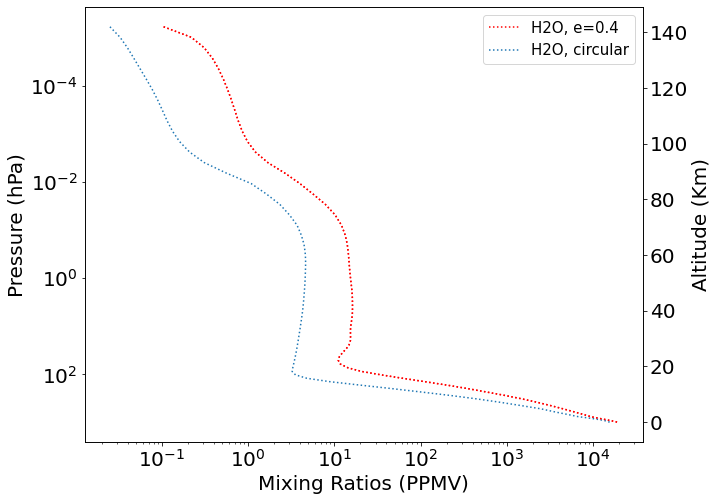

In [84]:
fig, ax1 = plt.subplots(figsize=(10,8))

ax2 = ax1.twinx()

H2O_e4_global_last5yr.plot(linestyle='dotted',color='r',y='lev',yscale='log',xscale='log',label='H2O, e=0.4',ax=ax1,yincrease=False)

H2O_circ_global_last5yr.plot(linestyle='dotted',color='#1f77b4',y='lev',yscale='log',xscale='log',label='H2O, circular',ax=ax1,yincrease=False)

ax2.plot(H2O_e4_global_last5yr,Z_e04.values,color='r',linestyle='dotted')

ax2.set_xscale('log')

ax1.legend(fontsize=15)

ax2.set_xlabel('Mixing Ratios (PPMV)',fontsize=20)

ax2.set_ylabel('Altitude (Km)',fontsize=20)

ax1.set_xlabel('Mixing Ratios (PPMV)',fontsize=20)

ax1.set_ylabel('Pressure (hPa)',fontsize=20)

ax1.tick_params(labelsize=20)
ax2.tick_params(labelsize=20)

print('this is the last 5 yr H2O MR')

In [85]:
T_e4_global_tot   =[]

for ii in range(8):
    T_e4_global_tot.append(LatWeightAnyVar(T_obl0_circ[1].T[ii*12:(ii+1)*12]))

T_circ_global_tot   =[]

for ii in range(8):
    T_circ_global_tot.append(LatWeightAnyVar(T_obl0_circ[0].T[ii*12:(ii+1)*12]))
    

def check_tropopause(DS):
    
    refinedlist=list(reversed(np.diff(DS.values)))
    
    tps = []
    
    for i in refinedlist:
        if i <0:
            tps.append(refinedlist.index(i))
    
    tps  =[i for i in tps if i >20]
    
    return tps[0]
    
tropopause_series_e4=[]
for i in range(len(T_e4_global_tot)):
    tropopause_series_e4.append(check_tropopause(T_e4_global_tot[i]))

print('for e=0.4, the tropopause position in Z axis is', tropopause_series_e4)

tropopause_series_circ=[]

for i in range(len(T_circ_global_tot)):
    
    tropopause_series_circ.append(check_tropopause(T_circ_global_tot[i]))

print('for circular case, the tropopause position in Z axis is', tropopause_series_circ)



for e=0.4, the tropopause position in Z axis is [22, 23, 23, 23, 23, 23, 23, 23]
for circular case, the tropopause position in Z axis is [22, 22, 22, 22, 22, 22, 22, 22]


In [86]:
tropopause_series_e4_monthly=[]

T_e4_global_mon   =[]

for ii in range(13*12):
    T_e4_global_mon.append(LatWeightAnyVar(T_obl0_circ[1].T[ii]))

for i in range(len(T_e4_global_mon)):
    tropopause_series_e4_monthly.append(check_tropopause(T_e4_global_mon[i]))

print('for e=0.4, the monthly tropopause position in Z axis is', tropopause_series_e4_monthly)

tropopause_series_circ_monthly=[]

T_circ_global_mon   =[]

for ii in range(13*12):
    T_circ_global_mon.append(LatWeightAnyVar(T_obl0_circ[0].T[ii]))

for i in range(len(T_circ_global_mon)):
    tropopause_series_circ_monthly.append(check_tropopause(T_circ_global_mon[i]))

print('for e=0, the monthly tropopause position in Z axis is', tropopause_series_circ_monthly)






























































































































































for e=0.4, the monthly tropopause position in Z axis is [22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 23, 25, 25, 25, 24, 24, 23, 23, 22, 22, 22, 23, 23, 25, 25, 25, 25, 24, 23, 23, 23, 22, 22, 22, 23, 25, 26, 25, 25, 24, 23, 23, 23, 22, 22, 23, 24, 25, 26, 25, 25, 24, 24, 23, 23, 22, 22, 23, 24, 25, 26, 25, 25, 24, 24, 23, 23, 22, 22, 23, 23, 25, 25, 25, 25, 24, 24, 23, 22, 22, 22, 23, 24, 25, 25, 25, 25, 24, 24, 23, 23, 22, 22, 23, 23, 25, 26, 25, 25, 24, 24, 23, 23, 22, 22, 23, 24, 25, 25, 26, 25, 24, 24, 23, 23, 22, 22, 23, 23, 25, 26, 25, 25, 24, 24, 23, 23, 22, 22, 23, 23, 25, 25, 25, 25, 24, 24, 23, 23, 22, 22, 23, 23, 25, 26, 25, 25, 24, 24, 23, 23, 22, 22, 23, 23]




























































































































































for e=0

In [87]:
# print(H2O_e4_global.values[-26])
print(H2O_circ_global.values[-22])


3.632136089974156


In [88]:
H2O_circ_global.values[-23]

3.342154919142159

In [89]:
(H2O_e0_global+H2_e0_global+H_e0_global+CH4_e0_global)[0].values

array(16.77319581)

In [90]:
print(H2O_e0_global.values[-23])
print(H2O_e04_global.values[-31])

3.505029380416429
35.1214263388201


In [91]:
print("The total water MR at homopause for circular is",(H2O_circ_global+H2_circ_global+H_circ_global+CH4_circ_global).values[11])

print("The total water MR at homopause for e=0.4 is",(H2O_e4_global+H2_e4_global+H_e4_global+CH4_e4_global).values[11])

The total water MR at homopause for circular is 5.18270971154033
The total water MR at homopause for e=0.4 is 11.244295497338564


In [92]:
print('the homopause at 100 km has pressure (hPa)',T_e04_global.lev.values[11])

the homopause at 100 km has pressure (hPa) 0.001458457461467333


In [93]:
H2O_e04_global

<xarray.DataArray 'H2O' (lev: 70)>
dask.array<mul, shape=(70,), dtype=float64, chunksize=(70,), chunktype=numpy.ndarray>
Coordinates:
  * lev      (lev) float64 5.96e-06 9.827e-06 1.62e-05 ... 957.5 976.3 992.6

In [94]:
(H2O_e0_global+H2_e0_global+H_e0_global+CH4_e0_global).values

print("4.79855944e+00")

4.79855944e+00


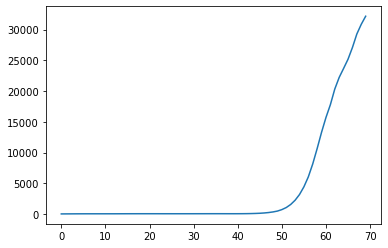

In [95]:
plt.plot((H2O_e04_global+H2_e04_global).values)

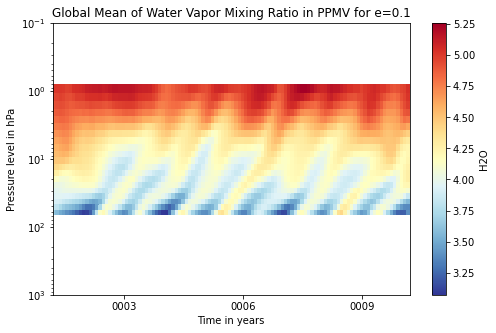

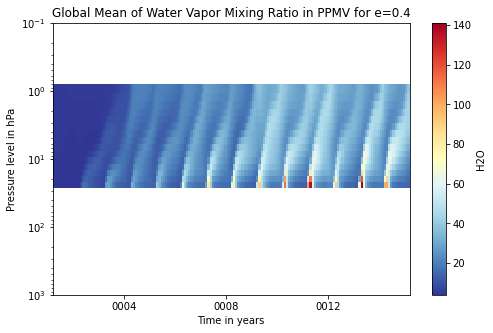

In [96]:
#fig, axes = plt.subplots()

# for stratopause 

H2O_e01_time= LatWeightAnyVar_timeframe(H2O_obl0[1].H2O[:,-44:-24,:,:])*10**6 

H2O_e04_time= LatWeightAnyVar_timeframe(H2O_obl0[4].H2O[:,-44:-29,:,:])*10**6 


H2O_e01_time.plot(x='time',cmap='RdYlBu_r',yscale='log',yincrease=False,figsize=(8,5))#,vmin=2, vmax=7)
plt.ylim([1000,0.1])

plt.title('Global Mean of Water Vapor Mixing Ratio in PPMV for e=0.1',fontsize=12)
plt.xlabel('Time in years')
plt.ylabel("Pressure level in hPa")
plt.show()

H2O_e04_time.plot(x='time',cmap='RdYlBu_r',yscale='log',yincrease=False,figsize=(8,5))#,vmin=10,vmax=90)
plt.title('Global Mean of Water Vapor Mixing Ratio in PPMV for e=0.4',fontsize=12)
plt.xlabel('Time in years')
plt.ylabel("Pressure level in hPa")
plt.ylim([1000,0.1])

plt.show()

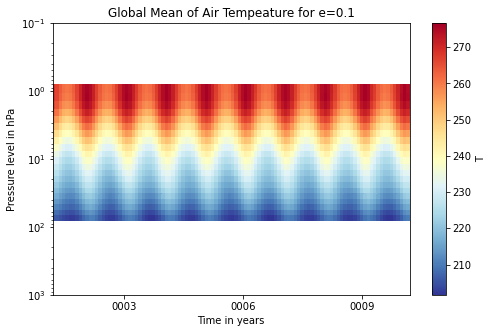

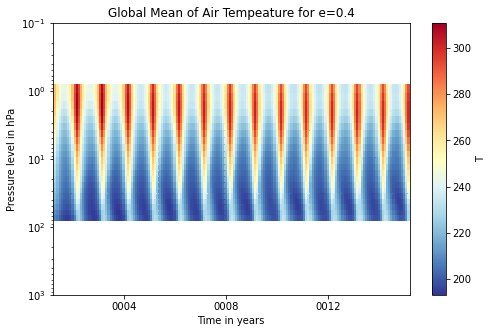

In [97]:
# for stratopause 

T_e01_time= LatWeightAnyVar_timeframe(T_obl0[1].T[:,-44:-23,:,:])

T_e04_time= LatWeightAnyVar_timeframe(T_obl0[4].T[:,-44:-23,:,:])


T_e01_time.plot(x='time',cmap='RdYlBu_r',yscale='log',yincrease=False,figsize=(8,5))#,ax=axes)#,vmin=8000, vmax=10000)
plt.ylim([1000,0.1])
plt.title('Global Mean of Air Tempeature for e=0.1',fontsize=12)
plt.xlabel('Time in years')
plt.ylabel("Pressure level in hPa")
plt.show()

T_e04_time.plot(x='time',cmap='RdYlBu_r',yscale='log',yincrease=False,figsize=(8,5))#,ax=axes)
plt.ylim([1000,0.1])
plt.title('Global Mean of Air Tempeature for e=0.4',fontsize=12)
plt.xlabel('Time in years')
plt.ylabel("Pressure level in hPa")
plt.show()

In [98]:
print('H2O_MR_E01_coldtrap',H2O_e01_global.values[-24]*10**6)

print('Lev',H2O_e01_global.lev.values[-24])

print('H2O_MR_E01_coldtrap',H2O_e04_global.values[-29]*10**6)

print('Lev',H2O_e04_global.lev.values[-29])

H2O_MR_E01_coldtrap 3614008.1595688886
Lev 73.75095784664154
H2O_MR_E01_coldtrap 40062089.366253875
Lev 29.7279991209507


Text(0.5, 1.0, 'O2 Mixing Ratios')

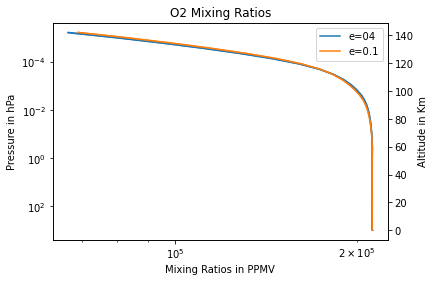

In [99]:
fig, ax1 = plt.subplots()

ax2 = ax1.twinx()

O2_e04_global.plot(y='lev',yscale='log',xscale='log',label='e=04',ax=ax1, yincrease=False)

O2_e01_global.plot(y='lev',yscale='log',xscale='log',label='e=0.1',ax=ax1, yincrease=False)

ax2.plot(O2_e04_global.values,Z_e04.values,label='e=04')

ax2.plot(O2_e01_global.values,Z_e0.values,label='e=0.1')

ax2.set_xscale('log')

ax2.legend()

ax2.set_xlabel('Mixing Ratios in PPMV')

ax2.set_ylabel('Altitude in Km')

ax1.set_xlabel('Mixing Ratios in PPMV')

ax1.set_ylabel('Pressure in hPa')

plt.title('O2 Mixing Ratios')

In [100]:
# find the corresponding pressure of 100 km homopuase

h=100  # 100 km homopause

H_e04=scale_height(T_e04_global).values

p_homo_e04=T_e04_global.lev[-1].values*np.exp(-h/H_e04)

print('p_homo_e04',p_homo_e04)


H_e0=scale_height(T_e0_global).values

p_homo_e0=T_e0_global.lev[-1].values*np.exp(-h/H_e0)

print('p_homo_e0',p_homo_e0)

T_air 256.09137960790605
p_homo_e04 0.0016085319763592045
T_air 256.45656430810845
p_homo_e0 0.0016393621688813164


In [101]:
from astropy.table import QTable

import astropy.units as u

Species = np.array(['H', 'OH', 'H2','H2O'])


MR_e0     = [H_e0_global.values[11], OH_e0_global.values[11],H2_e0_global.values[11],H2O_e0_global.values[11]]


MR_e04    = [H_e04_global.values[11], OH_e04_global.values[11],H2_e04_global.values[11],H2O_e04_global.values[11]]

t = QTable([Species, MR_e0, MR_e04],
           
names=('Species', 'MR_e0(model top 0.00145846)','MR_e04(model top 0.00145846)'))


t
           

Species,MR_e0(model top 0.00145846),MR_e04(model top 0.00145846)
str3,float64,float64
H,1.8181909032622545,9.376535825351198
OH,0.00015453250679520037,0.0003105790632295954
H2,3.312599543431055,21.931338063361203
H2O,0.21799312978779245,3.386603956775717


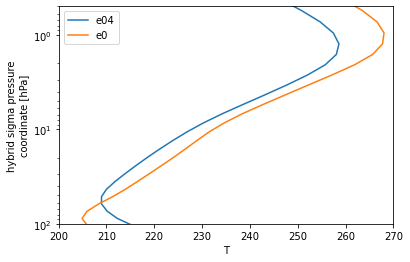

In [102]:
T_e04_thermo=LatWeightAnyVar(T_obl0[4].T)

T_e04_thermo.plot(y='lev',yscale='log',label='e04',yincrease=False)

T_e0_thermo=LatWeightAnyVar(T_obl0[0].T)

T_e0_thermo.plot(y='lev',yscale='log',label='e0',yincrease=False)

plt.ylim([100,0.5])

plt.xlim([200,270])

plt.legend()


In [103]:
# for stratopause 

# lev[-22] conventional 100 mb level (tropopause) e04 e01

T_e0_thermo.values

KeyboardInterrupt: 

In [ ]:
# x=ch4vmr_obl0[3].ch4vmr.time
# y=ch4vmr_obl0[3].ch4vmr.values

# #################### how to make y unit ppmv with xarray.plot??????

# fig, ax = plt.subplots()


# # plot two identical plots
# ax.plot(x, y)

# scale_y = 1e6
# ticks_y = ticker.FuncFormatter(lambda x, pos: '{0:g}'.format(x*scale_y))
# ax.yaxis.set_major_formatter(ticks_y)

# ax.set_ylabel('CH4 mixing ratios in ppmv')
# ax.set_xlabel('time in month')

# # vertically integrated co2 mixing ratio in ppmv

In [ ]:
# x=ch4vmr_obl0[4].ch4vmr.time
# y=ch4vmr_obl0[4].ch4vmr.values

# #################### how to make y unit ppmv with xarray.plot??????

# fig, ax = plt.subplots()


# # plot two identical plots
# ax.plot(x, y)

# scale_y = 1e6
# ticks_y = ticker.FuncFormatter(lambda x, pos: '{0:g}'.format(x*scale_y))
# ax.yaxis.set_major_formatter(ticks_y)

# ax.set_ylabel('CH4 mixing ratios in ppmv')
# ax.set_xlabel('time in month')

# # vertically integrated co2 mixing ratio in ppmv

In [ ]:
File_h0 = "/nobackup/pybl/cesm2/archive/b.e21.BWma1850.f19_g17.e0_obl0.001/atm/hist/b.e21.BWma1850.f19_g17.e0_obl0.001.cam.h0.0001-03.nc" #file name

DataSet_h0 = xr.open_dataset(File_h0,decode_times=False) #open the file and decode time as false

gw = DataSet_h0.gw.values

Pressure = DataSet_h0.lev.values

gw = DataSet_h0.gw.values

#%% define latitudinal weighting function

def LatWeightAnyVar(DS, time = False):
    try:
        DS = DS.mean(dim='lon')#take longitudinal mean
    except:
        print('')
    DS = gw*DS #multiply by gaussian weights
    try:
        DS = np.sum(DS,axis=1)/gw.sum() #weighted mean
    except:
        DS = np.sum(DS,axis=0)/gw.sum() #weighted mean 
    return DS #return a numpy array that has been modified above

In [ ]:
H2O_obl0_1 = xr.open_mfdataset('/nobackup/pybl/cesm2/archive/b.e21.BWma1850.f19_g17.e01_obl0_branch.001/atm/hist/H2O_e01_obl0.nc')

#%% define ozone column calculation function

def O3_col(ds, time = False, O2_mr = 0.21, lon = True):
    
    g = 9.80616           # gravity acceleration (cm/sec2)
    
    to_DU = 1./2.6867e20  # convert colunm density / cm^2 to Dobson units
    
    N2_mr = 1-O2_mr       # nitrogen mixing ratio
    
    m_avg = ((28*N2_mr)+(O2_mr*32))*1.661e-27 
                          # average weight of atmosphere
                          # calcualte column integrals 
    O3 = ds['O3']         # variables to calcualate hybrid pressure on model interfaces
    
    ps = ds['PS'].values  # surface pressure
    
    p0 =  H2O_obl0_1.P0.values  # constant 
    
    hyai = H2O_obl0_1.hyai.values # constant 
    
    hybi = H2O_obl0_1.hybi.values      # constant
    
    print('P0=',p0)
    print('hyai=',hyai)
    print('hybi=',hybi)
    
    dp = np.ndarray(O3.shape, np.float32)
    
    nt = 1
    try:
        nt = ds['time'].size
    except:
        nt = 0
        
    ny = ds['lat'].size
    nz = ds['lev'].size
    nx = ds['lon'].size
    press = np.ndarray(nz, np.float32)

    
    if (nt > 0):
        for i in range(nt):
            for j in range(ny):
                for k in range(nx):
                    press = hyai * p0 + hybi * ps[i,j,k]
                    for iz in range(nz):
                        dp[i,iz,j,k] = (press[iz+1]-press[iz]) 
    else:
        for j in range(ny):
            for k in range(nx):
                press = hyai * p0 + hybi * ps[j,k]
                for iz in range(nz):
                    dp[iz,j,k] = (press[iz+1]-press[iz])
                    
    #calcualte column integrals 
    O3_mid = O3 * dp / (m_avg*g)
    
    o3col = np.sum(O3_mid, axis = 1) * to_DU           # convert to DU
                                                   # integrate by summing small chunks
    if (lon == False):
        
        o3col  = o3col.mean(dim='lon')
        
    if (time == False):
        
        try:
            o3col  = o3col.mean(dim='time')
        except:
            o3col  = o3col
    print('O3 columns calculated')
    return o3col


In [ ]:
O3_col=O3_col(O3_obl0[4], time = False, O2_mr = 0.21, lon = True)

In [ ]:
O3_col.plot()

In [ ]:
# test if hyai is a constant

H2O_obl0_1 = xr.open_mfdataset('/nobackup/pybl/cesm2/archive/b.e21.BWma1850.f19_g17.e01_obl0_branch.001/atm/hist/H2O_e01_obl0.nc')
H2O_obl0_4 = xr.open_mfdataset('/nobackup/pybl/cesm2/archive/b.e21.BWma1850.f19_g17.e04_obl0_branch.001/atm/hist/H2O_e04_obl0.nc')

print((H2O_obl0_4.hyai.values==H2O_obl0_1.hyai.values).all())
print((H2O_obl0_4.hybi.values==H2O_obl0_1.hybi.values).all())
print((H2O_obl0_4.P0.values==H2O_obl0_1.P0.values).all())

In [ ]:
def LatWeightAnyVar_lat(DS,lat_low,lat_high,timemean,withlev): #Latitudinal weighting function for any latitudinal bands
    
    DS = DS.mean(dim='lon') #take longitudinal mean
    
    global DS_gw
    global gw_lat
    DS_gw=0
    
 
    gw_lat =0

    
    if (timemean == True) and (withlev == True):
        DS = DS.mean(dim='time')#take time mean

        for i in range(len(DS.lat)):
        
            if DS.lat[i] >= lat_low and DS.lat[i] <= lat_high :
            
                DS_gw  += DS[:,i]*gw[i] # multiply by gaussian weights
            
                gw_lat += gw[i]
                
        DS_gw_final = DS_gw.values/gw_lat
        
        
    if (timemean == True) and (withlev == False):
        DS = DS.mean(dim='time')      #take time mean

        for i in range(len(DS.lat)):
        
            if DS.lat[i] >= lat_low and DS.lat[i] <= lat_high :
            
                DS_gw  += DS[i]*gw[i] # multiply by gaussian weights
            
                gw_lat += gw[i]
                
            #print(DS_gw)
        DS_gw_final = DS_gw.values/gw_lat
        
    if (timemean == False) and (withlev == True):

        for i in range(len(DS.lat)):
        
            if DS.lat[i] >= lat_low and DS.lat[i] <= lat_high :
            
                DS_gw  += DS[:,:,i]*gw[i] # multiply by gaussian weights
            
                gw_lat += gw[i]
                
            #print(DS_gw)
        DS_gw_final = DS_gw.values/gw_lat
        
    elif (timemean == False) and (withlev == False):
            
        for i in range(len(DS.lat)):
        
            if DS.lat[i] >= lat_low and DS.lat[i] <= lat_high :
            
                DS_gw  += DS[:,i]*gw[i] # multiply by gaussian weight
            
                gw_lat += gw[i]
                
            #print(DS_gw)
    
        DS_gw_final = DS_gw.values/np.sum(gw_lat)
        
    return DS_gw_final 

In [ ]:
def LatWeightAnyVar_lat_test(DS,lat_low,lat_high,timemean,withlev): #Latitudinal weighting function for any latitudinal bands

    DS = DS.mean(dim='lon') #take longitudinal mean
    
    if (timemean == True) and (withlev == True):
        
        DS = DS.mean(dim='time')#take time mean

        DS =DS[:,lat_low:lat_high] # selecting tropical region

        DS = gw[lat_low:lat_high]*DS #multiply by gaussian weights
        
        DS = np.sum(DS,axis=1)/gw[lat_low:lat_high].sum() #weighted mean

        
    if (timemean == False) and (withlev == True):
        
        #DS = DS.mean(dim='time')#take time mean

        DS =DS[:,:,lat_low:lat_high] # selecting tropical region

        DS = gw[lat_low:lat_high]*DS #multiply by gaussian weights
        
        DS = np.sum(DS,axis=2)/gw[lat_low:lat_high].sum() #weighted mean

    return DS

In [ ]:
H2O_e01_trop_annomly=((LatWeightAnyVar_lat_test(H2O_obl0[1].H2O[:,-44:-24,:,:]*10**6,lat_low=36,lat_high=-36,timemean=False,withlev=True))-LatWeightAnyVar_lat_test(H2O_obl0[1].H2O[:,-44:-24,:,:]*10**6,lat_low=36,lat_high=-36,timemean=True,withlev=True))
H2O_e01_trop_annomly.plot(x='time',cmap='RdYlBu_r',yscale='log',yincrease=False,figsize=(8,5))
plt.title('Stratosphere H2O Mixing Ratio Anomaly for e=0.1',fontsize=15)
#

In [ ]:
H2O_obl0[1].H2O.lat[0:2]

In [ ]:
H2O_e04_trop_annomly=((LatWeightAnyVar_lat_test(H2O_obl0[4].H2O[:,-44:-24,:,:]*10**6,lat_low=36,lat_high=-36,timemean=False,withlev=True))-LatWeightAnyVar_lat_test(H2O_obl0[4].H2O[:,-44:-24,:,:]*10**6,lat_low=36,lat_high=-36,timemean=True,withlev=True))
H2O_e04_trop_annomly.plot(x='time',cmap='RdYlBu_r',yscale='log',yincrease=False,figsize=(8,5))
plt.title('Stratosphere H2O Mixing Ratio Anomaly for e=0.4',fontsize=15)

In [ ]:
T_e01_trop_annomly=((LatWeightAnyVar_lat_test(T_obl0[1].T[:,-44:-24,:,:],lat_low=36,lat_high=-36,timemean=False,withlev=True))-LatWeightAnyVar_lat_test(T_obl0[1].T[:,-44:-24,:,:],lat_low=36,lat_high=-36,timemean=True,withlev=True))
T_e01_trop_annomly.plot(x='time',cmap='RdYlBu_r',yscale='log',yincrease=False,figsize=(8,5))
plt.title('Stratosphere Temperature Anomaly for e=0.1',fontsize=15)
#

In [ ]:
T_e01_trop= LatWeightAnyVar_lat_test(T_obl0[1].T[:,-44:-23,:,:],lat_low=36,lat_high=-36,timemean=False,withlev=True)

T_e01_trop.plot(x='time',cmap='RdYlBu_r',yscale='log',yincrease=False,figsize=(8,5))
plt.title('Stratospheric Temperature for e=0.1')
plt.show()

T_e01_trop[:,-1].plot()

plt.title('Cold Trap Temperature for e=0.1',fontsize=15)

#


In [ ]:
T_e04_trop_annomly=((LatWeightAnyVar_lat_test(T_obl0[4].T[:,-44:-24,:,:],lat_low=36,lat_high=-36,timemean=False,withlev=True))-LatWeightAnyVar_lat_test(T_obl0[4].T[:,-44:-24,:,:],lat_low=36,lat_high=-36,timemean=True,withlev=True))
T_e04_trop_annomly.plot(x='time',cmap='RdYlBu_r',yscale='log',yincrease=False,figsize=(8,5))
plt.title('Stratosphere Temperature Anomaly for e=0.4',fontsize=15)

In [ ]:
T_e0_trop = LatWeightAnyVar_lat_test(T_obl0[0].T[:,-44:-23,:,:],lat_low=36,lat_high=-36,timemean=False,withlev=True).isel(time=slice(48, 96))
T_e04_trop= LatWeightAnyVar_lat_test(T_obl0[4].T[:,-44:-26,:,:],lat_low=36,lat_high=-36,timemean=False,withlev=True).isel(time=slice(120, 168))


T_e04_trop.plot(x='time',cmap='RdYlBu_r',yscale='log',yincrease=False,figsize=(8,5))
plt.title('Stratospheric Temperature for e=0.4')
plt.show()

T_e0_trop.plot(x='time',cmap='RdYlBu_r',yscale='log',yincrease=False,figsize=(8,5))
plt.title('Stratospheric Temperature for e=0.0167')
plt.show()

T_e04_trop[:,-1].plot()

T_e0_trop[:,-1].plot()

plt.figure(figsize=(10,8))
plt.plot(range(48),T_e04_trop[:,-1].values,label='e=0.4',color='r')

plt.axhline(np.mean(T_e04_trop[:,-1].values),label='e=0.4, mean',linestyle='dotted',color='r')

plt.plot(range(48),T_e0_trop[:,-1].values,label=r'$e \approx %0.004f$'%0.0167)

plt.axhline(np.mean(T_e0_trop[:,-1].values),label=r'$e \approx %0.004f$, mean'%0.0167,linestyle='dotted')

plt.xticks(range(0,60,12),labels=['0','1','2','3','4'])

plt.legend(fontsize=15)

plt.xlabel('Time (Year)',fontsize=20)

plt.ylabel('Temperature (Kelvin)',fontsize=20)

plt.tick_params(labelsize=20)

print('mean temp for e04',np.mean(T_e04_trop[:,-1].values))
print('mean temp for e0',np.mean(T_e0_trop[:,-1].values))

In [ ]:
# TTT for new experiment:
T_e_circ_trop=[]

for i in range(len(tropopause_series_circ_monthly)):
    
    T_e_circ_trop.append(LatWeightAnyVar_lat_test(T_obl0_circ[0].T[:,-44:-1*tropopause_series_circ_monthly[i],:,:],lat_low=36,lat_high=-36,timemean=False,withlev=True).isel(time=i))
    
T_e4_trop=[]

for i in range(len(tropopause_series_e4_monthly)):
    
    T_e4_trop.append(LatWeightAnyVar_lat_test(T_obl0_circ[1].T[:,-44:-1*tropopause_series_e4_monthly[i],:,:],lat_low=36,lat_high=-36,timemean=False,withlev=True).isel(time=i))

    
# T_e4_trop     = LatWeightAnyVar_lat_test(T_obl0_circ[1].T[:,-44:-24,:,:],lat_low=36,lat_high=-36,timemean=False,withlev=True).isel(time=slice(0,96))


# T_e4_trop.plot(x='time',cmap='RdYlBu_r',yscale='log',yincrease=False,figsize=(8,5))

# plt.title('Stratospheric Temperature for e=0.4')
# plt.show()

# T_e_circ_trop.plot(x='time',cmap='RdYlBu_r',yscale='log',yincrease=False,figsize=(8,5))
# plt.title('Stratospheric Temperature for circular case')
# plt.show()

# T_e04_trop[:,-1].plot()

TTT_circ=[]

for i in range(156):
    TTT_circ.append(T_e_circ_trop[i][-1].T.values)

TTT_e4=[]

for i in range(156):
    TTT_e4.append(T_e4_trop[i][-1].T.values)
    
plt.plot(range(156),TTT_e4)
plt.show()

# plt.figure(figsize=(10,8))

# plt.plot(range(96),T_e4_trop[:,-1].values,label='e=0.4',color='r')

# plt.axhline(np.mean(T_e4_trop[:,-1].values),label='e=0.4, mean',linestyle='dotted',color='r')

# plt.plot(range(96),T_e_circ_trop[:,-1].values,label="circular")

# plt.axhline(np.mean(T_e_circ_trop[:,-1].values),label="circular",linestyle='dotted')

# plt.xticks(range(0,96,12),labels=['1','2','3','4','5','6','7','8'])

# plt.legend(fontsize=15)

# plt.xlabel('Time (Year)',fontsize=20)

# plt.ylabel('Temperature (Kelvin)',fontsize=20)

# plt.tick_params(labelsize=20)

# print('mean temp for e04',np.mean(T_e04_trop[-12:,-1].values))
# print('mean temp for e0',np.mean(T_e_circ_trop[-12:,-1].values))

In [ ]:
len(tropopause_series_circ_monthly)

In [ ]:
T_e4_trop[0]

In [ ]:
plt.figure(figsize=(10,8))

plt.plot(range(156),TTT_e4,label='e=0.4',color='r')

plt.axhline(np.mean(TTT_e4),label='e=0.4, mean',linestyle='dotted',color='r')

plt.plot(range(156),TTT_circ,label='circular')

plt.axhline(np.mean(TTT_circ),label='circular, mean',linestyle='dotted')

plt.xticks(range(0,156,12),labels=['1','2','3','4','5','6','7','8','9','10','11','12','13'])

plt.legend(fontsize=15)

plt.xlabel('Time (Year)',fontsize=20)

plt.ylabel('Temperature (Kelvin)',fontsize=20)

plt.tick_params(labelsize=20)
plt.minorticks_on()
plt.show()

print(np.mean(TTT_circ))
print(np.mean(TTT_e4))

In [ ]:
annual_mean_TTT =[[],[]]
TTT = [TTT_circ,TTT_e4]

for i in range(2):
    for ii in range(10):
        annual_mean_TTT[i].append(np.mean(TTT[i][ii*12:(ii+1)*12]))

plt.figure(figsize=(10,8))

plt.plot(range(1,11), annual_mean_TTT[0],label="circular")

plt.plot(range(1,11), annual_mean_TTT[1],label='e=0.4',color='r')

plt.axhline(np.mean(annual_mean_TTT[0]),label="circular, mean",linestyle='dotted')

plt.axhline(np.mean(annual_mean_TTT[1]),label="e=0.4, mean",linestyle='dotted',color='r')

plt.xlabel('Time (Year)',fontsize=20)
plt.ylabel('Temperature (Kelvin)',fontsize=20)
plt.tick_params(labelsize=20)
plt.legend(fontsize=20)

print(np.mean(annual_mean_TTT[0]))
print(np.mean(annual_mean_TTT[1]))

print('TTT mean for the last simulation year, circular',np.mean(annual_mean_TTT[0][-1]))
print('TTT mean for the last simulation year, e=0.4',np.mean(annual_mean_TTT[1][-1]))

In [ ]:
print(LatWeightAnyVar(T_obl0_circ[1].T[:,:,:,:]).values) 
print(LatWeightAnyVar(T_obl0_circ[0].T[:,:,:,:]).values) 

But, how should I quantify this correlation?

In [ ]:
# Tropical tropopause temperature
TTPT_e_default_mean = LatWeightAnyVar_lat(T_obl0[0].T[:,-23,:,:],lat_low=-23.5,lat_high=23.5,timemean=True,withlev=False)

#TTPT_e01_mean = LatWeightAnyVar_lat(T_obl0[1].T[:,-23,:,:],lat_low=-23.5,lat_high=23.5,timemean=True,withlev=False)

TTPT_e04_mean = LatWeightAnyVar_lat(T_obl0[4].T[:,-26,:,:],lat_low=-23.5,lat_high=23.5,timemean=True,withlev=False)

print('The time average of tropical tropopause temperature for e_default in K',TTPT_e_default_mean)

#print('The time average of tropical tropopause temperature for e01 in K',TTPT_e01_mean)

print('The time average tropical tropopause temperature for e04 in K',TTPT_e04_mean)   

In [ ]:
TTPT_e_default= LatWeightAnyVar_lat(T_obl0[0].T[:,-23,:,:],lat_low=-23.5,lat_high=23.5,timemean=False,withlev=False)
#TTPT_e01= LatWeightAnyVar_lat(T_obl0[1].T[:,-23,:,:],lat_low=-23.5,lat_high=23.5,timemean=False,withlev=False)
#TTPT_e02= LatWeightAnyVar_lat(T_obl0[2].T[:,-23,:,:],lat_low=-23.5,lat_high=23.5,timemean=False,withlev=False)
#TTPT_e03= LatWeightAnyVar_lat(T_obl0[3].T[:,-24,:,:],lat_low=-23.5,lat_high=23.5,timemean=False,withlev=False)
TTPT_e04= LatWeightAnyVar_lat(T_obl0[4].T[:,-26,:,:],lat_low=-23.5,lat_high=23.5,timemean=False,withlev=False)



plt.figure(figsize=(10,8))



plt.plot(TTPT_e04,label='e=0.4',color='red')
plt.plot(TTPT_e_default,label=r'$e \approx %0.004f$'%0.0167)
#plt.plot(TTPT_e01,label='e=01')
#plt.plot(TTPT_e02,label='e=02')
#plt.plot(TTPT_e03,label='e=03')


plt.xticks(range(0,168,12),labels=['1','2','3','4','5','6','7','8','9','10','11','12','13','14'])

plt.legend(loc='best',fontsize=20)
plt.ylabel("Temperature (Kelvin)",fontsize=20)
plt.tick_params(labelsize=20)
plt.xlabel("Time (Year)",fontsize=20)
#plt.title('Monthly Mean Tropical Tropopause Temperature')

print('note this is not fully correct because tropopause altitude increases with time')



In [ ]:
TTPT_e01_annual=[]

TTPT_e04_annual=[]

#for i in range(9):
   # TTPT_e01_annual.append(np.mean(TTPT_e01[i*12:(i+1)*12]))
    
for i in range(14):
    TTPT_e04_annual.append(np.mean(TTPT_e04[i*12:(i+1)*12]))


#plt.plot(TTPT_e01_annual,label='TTPT_e01')

plt.plot(TTPT_e04_annual,label='TTPT_e04')

plt.xticks(range(0,14),labels=['1','2','3','4','5','6','7','8','9','10','11','12','13','14'])

plt.legend()

plt.title('Annual Mean Tropical Tropopause Temperature')
print("As the tropopause altitude increases each year for e04 case, and tropical tropopause is different from the global," 
      +"so I take the 14 years time average"+
      " of vertical temperature and find the mean pressure level of tropopause")

In [ ]:
# for stratopause 

# lower limit is set [:,-44:-23,:,:] for e= 0.4 but to let them in the same scale, set both at z level [-28],
# but later, I think it does not make sense if we plot them in the same vertical lower limit because
# the cold trap clearly moved upward for higher eccentricity case.
# it should be -22, for the same value as T[-23]...

H2O_e_default_time_tr = LatWeightAnyVar_lat_test(H2O_obl0[0].H2O[:,-44:-25,:,:]*10**6,lat_low=36,lat_high=-36,timemean=False,withlev=True).isel(time=slice(47, 96))

H2O_e04_time_tr = LatWeightAnyVar_lat_test(H2O_obl0[4].H2O[:,-44:-25,:,:]*10**6,lat_low=36,lat_high=-36,timemean=False,withlev=True).isel(time=slice(119, 168))
##########################################################################################################

fig, axes = plt.subplots(2,figsize=(10,16))

H2O_e_default_time_tr.plot(x='time',cmap='RdYlBu_r',ax=axes[0],yscale='log',yincrease=False,cbar_kwargs={"label": "H2O Mixing Ratio in PPMV"})   #,vmin=2, vmax=7)

H2O_e_default_time_tr_contour=H2O_e_default_time_tr.plot.contour(x='time',cmap='gray',ax=axes[0],yscale='log',yincrease=False)

axes[0].clabel(H2O_e_default_time_tr_contour, inline=True, fontsize=20,fmt='%1.f')

#########################################################################################

H2O_e04_time_tr.plot(x='time',cmap='RdYlBu_r',ax=axes[1],yscale='log',yincrease=False,cbar_kwargs={"label": "H2O Mixing Ratio in PPMV"})#vmin=10,vmax=100)

H2O_e04_time_tr_contour=H2O_e04_time_tr.plot.contour(x='time',cmap='gray',ax=axes[1],yscale='log',yincrease=False)

axes[1].clabel(H2O_e04_time_tr_contour, inline=True, fontsize=20,fmt='%1.f')

#plt.title('Tropical Mean of Water Vapor Mixing Ratio in PPMV for e=0.4',fontsize=15)
axes[1].set_xlabel('Time (Year)',fontsize=20)
axes[1].set_ylabel("Pressure (hPa)",fontsize=20)
axes[1].set_ylim([51,0.9])
axes[1].set_yticks([51, 10, 1], [51, 10, 1])

# axes[1].set_xticks(range(0,60,12))
# axes[1].set_xticklabels(['0','1','2','3','4'])

labels = [item.get_text() for item in axes[1].get_xticklabels()]

labels= ['0','1','2','3','4']
axes[1].set_xticklabels(labels)


labels = [item.get_text() for item in axes[0].get_xticklabels()]

labels= ['0','1','2','3','4']
axes[0].set_xticklabels(labels)


axes[0].set_xlabel('Time (Year)',fontsize=20)
axes[0].set_ylabel("Pressure level (hPa)",fontsize=20)
axes[0].set_ylim([51,0.9])
axes[0].set_yticks([51, 10, 1], [51, 10, 1])
axes[0].tick_params(labelsize=20)
axes[1].tick_params(labelsize=20)
plt.show()
#########################################################################################################

In [ ]:
import matplotlib.gridspec as gridspec

# Create 2x2 sub plots

gs = gridspec.GridSpec(2, 2)

plt.figure(figsize=(20,16))

plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.8, 
                    top=0.8, 
                    wspace=0.5, 
                    hspace=0.5)

ax = plt.subplot(gs[0, :]) # row 0, span all columns

plt.plot(range(48),T_e04_trop[:,-1].values,label='e=0.4',color='r')

plt.axhline(np.mean(T_e04_trop[:,-1].values),label='e=0.4, mean',linestyle='dotted',color='r')

plt.plot(range(48),T_e0_trop[:,-1].values,label=r'$e \approx %0.004f$'%0.0167)

plt.axhline(np.mean(T_e0_trop[:,-1].values),label=r'$e \approx %0.004f$, mean'%0.0167,linestyle='dotted')

plt.xticks(range(0,60,12),labels=['0','1','2','3','4'])
plt.minorticks_on()


plt.legend(fontsize=15)

plt.xlabel('Time (Year)',fontsize=20)

plt.ylabel('Temperature (Kelvin)',fontsize=20)

plt.tick_params(labelsize=20)

print('mean temp for e04',np.mean(T_e04_trop[:,-1].values))
print('mean temp for e0',np.mean(T_e0_trop[:,-1].values))

ax = plt.subplot(gs[1, 0]) # row 1, col 0

H2O_e_default_time_tr.plot(x='time',cmap='RdYlBu_r',ax=ax,yscale='log',yincrease=False,cbar_kwargs={"label": "H2O Mixing Ratio in PPMV"})   #,vmin=2, vmax=7)

H2O_e_default_time_tr_contour=H2O_e_default_time_tr.plot.contour(x='time',cmap='gray',ax=ax,yscale='log',yincrease=False)

ax.clabel(H2O_e_default_time_tr_contour, inline=True, fontsize=20,fmt='%1.f')

ax.set_xlabel('Time (Year)',fontsize=20)
ax.set_ylabel("Pressure (hPa)",fontsize=20)
ax.set_ylim([51,0.9])
ax.set_yticks([51, 10, 1], [51, 10, 1])

# labels = [item.get_text() for item in ax.get_xticklabels()]

# labels= ['0','1','2','3','4']
# ax.set_xticklabels(labels)
plt.minorticks_on()

ax = plt.subplot(gs[1, 1]) # row 1, col 1

H2O_e04_time_tr.plot(x='time',cmap='RdYlBu_r',ax=ax,yscale='log',yincrease=False,cbar_kwargs={"label": "H2O Mixing Ratio in PPMV"})#vmin=10,vmax=100)

H2O_e04_time_tr_contour=H2O_e04_time_tr.plot.contour(x='time',cmap='gray',ax=ax,yscale='log',yincrease=False)

ax.clabel(H2O_e04_time_tr_contour, inline=True, fontsize=20,fmt='%1.f')

ax.set_xlabel('Time (Year)',fontsize=20)
ax.set_ylabel("Pressure (hPa)",fontsize=20)
ax.set_ylim([51,0.9])
ax.set_yticks([51, 10, 1], [51, 10, 1])

# labels = [item.get_text() for item in ax.get_xticklabels()]

# labels= ['0','1','2','3','4']
# ax.set_xticklabels(labels)
plt.minorticks_on()
plt.tight_layout()
plt.plot()



#plt.title('Monthly Mean Tropical Tropopause Temperature')

In [ ]:
labels = [item.get_text() for item in ax.get_xticklabels()]
labels

In [ ]:
# TT H2O for new experiment:

H2O_circ_trop=[]

for i in range(len(tropopause_series_circ_monthly)):
    
    H2O_circ_trop.append(LatWeightAnyVar_lat_test(H2O_obl0_circ[0].H2O[:,-44:-1*tropopause_series_circ_monthly[i],:,:],lat_low=36,lat_high=-36,timemean=False,withlev=True).isel(time=i)*10**6)
    
H2O_circ_trop = xr.concat(H2O_circ_trop, dim='time')

H2O_e4_trop=[]

for i in range(len(tropopause_series_e4_monthly)):
    
    H2O_e4_trop.append(LatWeightAnyVar_lat_test(H2O_obl0_circ[1].H2O[:,-44:-1*tropopause_series_e4_monthly[i],:,:],lat_low=36,lat_high=-36,timemean=False,withlev=True).isel(time=i)*10**6)

H2O_e4_trop = xr.concat(H2O_e4_trop, dim='time')

In [ ]:
import matplotlib.gridspec as gridspec

# Create 2x2 sub plots

gs = gridspec.GridSpec(2, 2)

plt.figure(figsize=(20,16))

plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.8, 
                    top=0.8, 
                    wspace=0.5, 
                    hspace=0.5)

ax = plt.subplot(gs[0, :]) # row 0, span all columns

plt.plot(range(156),TTT_e4,label='e=0.4',color='r')

plt.axhline(np.mean(TTT_e4),label='e=0.4, mean',linestyle='dotted',color='r')

plt.plot(range(156),TTT_circ,label='circular')

plt.axhline(np.mean(TTT_circ),label='circular,mean',linestyle='dotted')

plt.xticks(range(0,156,12),labels=['1','2','3','4','5','6','7','8','9','10','11','12','13'])
plt.minorticks_on()

plt.legend(fontsize=15)

plt.xlabel('Time (Year)',fontsize=20)

plt.ylabel('Temperature (Kelvin)',fontsize=20)

plt.tick_params(labelsize=20)

print('mean temp for e=04',np.mean(TTT_e4))
print('mean temp for circ',np.mean(TTT_circ))

# 

ax = plt.subplot(gs[1, 0]) # row 1, col 0


H2O_circ_trop.plot(x='time',cmap='RdYlBu_r',ax=ax,yscale='log',yincrease=False,cbar_kwargs={"label": "H2O Mixing Ratio in PPMV"})   #,vmin=2, vmax=7)

H2O_circ_trop_contour=H2O_circ_trop.plot.contour(x='time',cmap='gray',ax=ax,yscale='log',yincrease=False)

ax.clabel(H2O_circ_trop_contour, inline=True, fontsize=20,fmt='%1.f')

ax.set_xlabel('Time (Year)',fontsize=20)
ax.set_ylabel("Pressure (hPa)",fontsize=20)
ax.set_ylim([51,0.9])
ax.set_yticks([51, 10, 1], [51, 10, 1])

# labels = [item.get_text() for item in ax.get_xticklabels()]

# labels= ['0','1','2','3','4']
# ax.set_xticklabels(labels)
plt.minorticks_on()

ax = plt.subplot(gs[1, 1]) # row 1, col 1

H2O_e4_trop.plot(x='time',cmap='RdYlBu_r',ax=ax,yscale='log',yincrease=False,cbar_kwargs={"label": "H2O Mixing Ratio in PPMV"})#vmin=10,vmax=100)

H2O_e4_trop_contour=H2O_e4_trop.plot.contour(x='time',cmap='gray',ax=ax,yscale='log',yincrease=False)

ax.clabel(H2O_e4_trop_contour, inline=True, fontsize=20,fmt='%1.f')

ax.set_xlabel('Time (Year)',fontsize=20)
ax.set_ylabel("Pressure (hPa)",fontsize=20)
ax.set_ylim([51,0.9])
ax.set_yticks([51, 10, 1], [51, 10, 1])

plt.minorticks_on()
plt.tight_layout()
plt.plot()



#plt.title('Monthly Mean Tropical Tropopause Temperature')

In [ ]:
ax.annotate

In [ ]:
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import FormatStrFormatter

# Create 2x2 sub plots

gs = gridspec.GridSpec(3, 1, height_ratios=[1.3,2,2])

plt.figure(figsize=(10,15),constrained_layout=False)

plt.subplots_adjust(left=0.1,
                    bottom=0.2, 
                    right=0.8, 
                    top=0.8, 
                    wspace=0.5, 
                    hspace=0.5)

ax1 = plt.subplot(gs[0, :]) # row 0, span all columns

plt.tight_layout()

plt.plot(range(96-4,156-4),TTT_e4[96-4:156-4],label='e=0.4',color='r')

plt.axhline(np.mean(TTT_e4[96-4:156-4]),label='e=0.4, mean',linestyle='dotted',color='r',xmin=0,xmax=10*12)

plt.plot(range(96-4,156-4),TTT_circ[96-4:156-4],label='circular')

plt.axhline(np.mean(TTT_circ[96-4:156-4]),label='circular,mean',linestyle='dotted',xmin=0,xmax=10*12)

# add vertical lines to the plot to indicate perihelion and aphelion

xcoords_p = [93, 93+12, 93+12*2,93+12*3,93+12*4]
for xc in xcoords_p:
    plt.axvline(x=xc,color='grey',linestyle='dotted')
    
xcoords = [93+6, 93+12+6, 93+12*2+6,93+12*3+6,93+12*4+6]
for xc in xcoords:
    plt.axvline(x=xc,color='grey', alpha=0.5)
ax.xaxis.set_label_coords(1.05, -0.025)

plt.xticks(range(96-4,156+12-4,12),labels=['9','10','11','12','13','14'])

# ax1.fill_between(
#     np.append(T_e4_global_last5yr.T.values.tolist(), e4_APR_T.T.values.tolist()[::-1]),
#     np.append(T_e4_global_last5yr.lev.values.tolist(), e4_APR_T.lev.values.tolist()[::-1]), color='red',alpha=.2, linewidth=0
# )

plt.minorticks_on()

# plt.tick_params(axis='both', which='minor', labelsize=8)

plt.legend(loc='upper center', fontsize=15,ncol=4)

plt.xlabel('Time (Year)',fontsize=20)

plt.ylabel('Temperature (K)',fontsize=20)

plt.xlim(left=96-4,right=156-4)

plt.ylim(top=230)

plt.tick_params(axis='x',labelsize=20, which='minor',width=1,length=4)

plt.tick_params(axis='both',labelsize=20, which='major',width=1,length=6)

print('mean temp for e=04',np.mean(TTT_e4[96-4:156-4]))
print('mean temp for circ',np.mean(TTT_circ[96-4:156-4]))

# 

ax2 = plt.subplot(gs[1, :]) # row 1, col 0

fg=H2O_circ_trop.isel(time=slice(92, 153)).plot(x='time',cmap='RdYlBu_r',ax=ax2,yscale='log',yincrease=False,cbar_kwargs={'orientation': 'horizontal'})

H2O_circ_trop_contour=H2O_circ_trop.isel(time=slice(92, 153)).plot.contour(x='time',cmap='gray',ax=ax2,yscale='log',yincrease=False)
 
ax2.clabel(H2O_circ_trop_contour, inline=True, fontsize=20,fmt='%1.f')


ax2.tick_params(axis='x', which='minor')
plt.minorticks_on()
labels = [item.get_text() for item in ax2.get_xticklabels(which='minor')]
labels[0]='009'
labels[3]='0011'
labels[6]='0013'
ax2.set_xticklabels(labels,minor=True)


ax2.set_xlabel('Time (Year)',fontsize=20)

ax2.set_ylabel("Pressure (hPa)",fontsize=20)

# ax2.tick_params('both', which='both',labelsize=20)
ax2.tick_params(axis='both',labelsize=20, which='minor',width=1,length=4)

ax2.tick_params(axis='both',labelsize=20, which='major',width=1,length=6)


divider = make_axes_locatable(ax2)

divider.new_vertical(size='3%', pad=0.3, pack_start = True)

fg.colorbar.ax.tick_params(labelsize=15)

fg.colorbar.set_label(label="$\mathregular{H_2O}$ Mixing Ratio (ppmv)", size=15)



ax2.set_ylim([51,0.9])
ax2.set_yticks([51, 10, 1], [51, 10, 1])
plt.tight_layout()
plt.text(.99, .99, 'e=0', ha='right', va='top', transform=ax2.transAxes,fontsize=20)

#####


ax = plt.subplot(gs[2, :],sharex=ax2) # row 1, col 1

fg2=H2O_e4_trop.isel(time=slice(92, 153)).plot(x='time',cmap='RdYlBu_r',ax=ax,yscale='log',yincrease=False,cbar_kwargs={'orientation': 'horizontal'},vmax=30)

H2O_e4_trop_contour=H2O_e4_trop.isel(time=slice(92, 153)).plot.contour(x='time',cmap='gray',ax=ax,yscale='log',yincrease=False)

ax.clabel(H2O_e4_trop_contour, inline=True, fontsize=20,fmt='%1.f')

ax.tick_params(axis='x', which='minor')
plt.minorticks_on()
labels = [item.get_text() for item in ax.get_xticklabels(which='minor')]
labels[0]='009'
labels[3]='0011'
labels[6]='0013'
ax.set_xticklabels(labels,minor=True)
# ax.tick_params('both', which='both',labelsize=20)

ax.tick_params(axis='both',labelsize=20, which='minor',width=1,length=4)

ax.tick_params(axis='both',labelsize=20, which='major',width=1,length=6)

ax.set_xlabel('Time (Year)',fontsize=20)

ax.set_ylabel("Pressure (hPa)",fontsize=20)

# ax.tick_params('both', labelsize=20)

fg2.colorbar.ax.tick_params(labelsize=15)

divider = make_axes_locatable(ax)

divider.new_vertical(size='3%', pad=0.3, pack_start = True)

fg2.colorbar.set_label(label="$\mathregular{H_2O}$ Mixing Ratio (ppmv)", size=15)

plt.text(.99, .99, 'e=0.4', ha='right', va='top', transform=ax.transAxes,fontsize=20)

ax.set_ylim([51,0.9])
ax.set_yticks([51, 10, 1], [51, 10, 1])

plt.tight_layout()
plt.plot()

plt.savefig("TTT_WVMR.png",dpi=400,bbox_inches="tight")
# #plt.title('Monthly Mean Tropical Tropopause Temperature')

In [ ]:
print('mean temp for e=04',np.min(TTT_e4[96-4:156-4]))

In [ ]:
183.5108364605882-np.mean(TTT_e4[96-4:156-4])

In [ ]:
import pandas as pd
import xarray as xr

# create dataFrame
df = pd.DataFrame({'time':len(H2O_circ_trop),
                   'lev':H2O_circ_trop[0].lev
                   'H2O':[for ]}).set_index('time')

# convert to dataset
ds = df.to_xarray()

ds

In [ ]:

for i in range(len(H2O_circ_trop)):
    tt=xr.concat(H2O_circ_trop[i],dim='time')

    su

In [ ]:
xr.concat(H2O_circ_trop[0],H2O_circ_trop[1],dim='time')

In [ ]:
H2O_circ_trop[0].expand_dims(dim="time")
H2O_circ_trop[1].expand_dims(dim="time")


In [ ]:
H2O_e_default_time_tr.mean(dim='time').values

In [ ]:
H2O_e04_time_tr.mean(dim='time').values

In [ ]:
TTPT_e01_mean_v = LatWeightAnyVar_lat(T_obl0[1].T,lat_low=-23.5,lat_high=23.5,timemean=True,withlev=True)

TTPT_e04_mean_v = LatWeightAnyVar_lat(T_obl0[4].T,lat_low=-23.5,lat_high=23.5,timemean=True,withlev=True)



plt.plot(TTPT_e01_mean_v,T_obl0[1].T.lev,label='e01')

plt.plot(TTPT_e04_mean_v,T_obl0[1].T.lev,label='e04')

plt.gca().invert_yaxis()

plt.yscale('log')


plt.ylim([100,0.1])

plt.xlim([190,300])

plt.legend()

plt.title("Annual Mean of Tropical Air Temperature")

plt.xlabel('T in K')

plt.ylabel('Pressure in hPa')

In [ ]:
# the tropical tropopause pressure level is:

print("the tropical tropopause temperature  for e0 is (K):",LatWeightAnyVar(T_obl0[0].T[:,-23,:,:].mean(dim='time')).values)
print("the tropical tropopause pressure level for e0 is (hPa):",T_obl0[0].T.lev.values[-23])

print("the tropical tropopause temperature  for e04 is (K):",LatWeightAnyVar(T_obl0[4].T[:,-26,:,:].mean(dim='time')).values)
print("the tropical tropopause pressure level for e04 is (hPa):",T_obl0[4].T.lev.values[-26])

In [ ]:
LatWeightAnyVar(T_obl0[0].T[:,-23,:,:])

In [ ]:
fig, axes = plt.subplots()

Zonal_T4 = T_obl0[4].T.mean(dim='lon').mean(dim='time').plot.contour(x='lat',cmap='gray',ax=axes,yscale='log',yincrease=False)

axes.clabel(Zonal_T4, inline=True, fontsize=10,fmt='%1.f')

T_obl0[4].T.mean(dim='lon').mean(dim='time').plot(x='lat',cmap='RdYlBu_r',ax=axes,yscale='log',yincrease=False)

axes.set_title('Zonal Mean T for e=0.4')

plt.show()

###########################


In [ ]:
fig, axes = plt.subplots(figsize=(8,5))

Zonal_H2O4_pre = 10**6*H2O_obl0[4].H2O

Zonal_H2O4 =Zonal_H2O4_pre.mean(dim='lon').mean(dim='time').plot.contour(x='lat',cmap='gray',ax=axes,yscale='log',yincrease=False)

axes.clabel(Zonal_H2O4, inline=True, fontsize=10,fmt='%1.f')

Zonal_H2O4_pre.mean(dim='lon').mean(dim='time').plot(x='lat',cmap='RdYlBu_r',ax=axes,yscale='log',yincrease=False)

#axes.set_title('Zonal Mean H2O for e=0.4')

plt.ylim([1000,100])
plt.title('Annual, Zonal Mean H2O Mixing Ratio in PPMV for e=0.4')
plt.show()

###########################

In [ ]:
fig, axes = plt.subplots(figsize=(8,5))

Zonal_H2O1_pre = 10**6*H2O_obl0[1].H2O

Zonal_H2O1 =Zonal_H2O1_pre.mean(dim='lon').mean(dim='time').plot.contour(x='lat',cmap='gray',ax=axes,yscale='log',yincrease=False)

axes.clabel(Zonal_H2O1, inline=True, fontsize=10,fmt='%1.f')

Zonal_H2O1_pre.mean(dim='lon').mean(dim='time').plot(x='lat',cmap='RdYlBu_r',ax=axes,yscale='log',yincrease=False)

plt.title('Annual, Zonal Mean H2O Mixing Ratio in PPMV for e=0.1')

plt.ylim([1000,100])
plt.show()

###########################

In [ ]:
fig, axes = plt.subplots(figsize=(10,5))

QBO_e04 = U_obl0[4].U.where((U_obl0[4].lat > -23.5 ) & (U_obl0[4].lat < 23.5) & (U_obl0[4].lev < 100)& (U_obl0[4].lev > 0.9)).isel(time=slice(120, 168)).mean(['lon','lat']).plot.contour(x='time',cmap='gray',ax=axes,yscale='log',yincrease=False)

axes.clabel(QBO_e04, inline=True, fontsize=10,fmt='%1.f')

U_obl0[4].U.where((U_obl0[4].lat > -23.5 ) & (U_obl0[4].lat < 23.5) & (U_obl0[4].lev < 100)& (U_obl0[4].lev > 0.9)).isel(time=slice(120, 168)).mean(['lon','lat']).plot(x='time',cmap='RdYlBu_r',ax=axes,yscale='log',yincrease=False)

plt.ylim([30,0.9])
plt.yticks([30, 10, 1], [30, 10, 1])
plt.title('Demonstration of Monthly Mean QBO (m/s) for e = 0.4 in Tropics')
plt.show()
#########################################################################################################

fig, axes = plt.subplots(figsize=(10,5))

QBO_e_default = U_obl0[0].U.where((U_obl0[0].lat > -23.5 ) & (U_obl0[0].lat < 23.5) & (U_obl0[0].lev < 100)& (U_obl0[0].lev > 0.9)).isel(time=slice(48, 96)).mean(['lon','lat']).plot.contour(x='time',cmap='gray',ax=axes,yscale='log',yincrease=False)

axes.clabel(QBO_e_default, inline=True, fontsize=15,fmt='%1.f')

U_obl0[0].U.where((U_obl0[0].lat > -23.5 ) & (U_obl0[0].lat < 23.5) & (U_obl0[0].lev < 100)& (U_obl0[0].lev > 0.9)).isel(time=slice(48, 96)).mean(['lon','lat']).plot(x='time',cmap='RdYlBu_r',ax=axes,yscale='log',yincrease=False)
plt.ylim([30,0.9])
plt.yticks([30, 10, 1], [30, 10, 1])
plt.title('Demonstration of Monthly Mean QBO (m/s) for e = 0.0167 in Tropics')
plt.show()

#########################################################################################################

fig, axes = plt.subplots(figsize=(10,5))

QBO_e01 = U_obl0[1].U.where((U_obl0[1].lat > -23.5 ) & (U_obl0[1].lat < 23.5) & (U_obl0[1].lev < 100)& (U_obl0[1].lev > 0.9)).isel(time=slice(60, 108)).mean(['lon','lat']).plot.contour(x='time',cmap='gray',ax=axes,yscale='log',yincrease=False)

axes.clabel(QBO_e01, inline=True, fontsize=15,fmt='%1.f')

U_obl0[1].U.where((U_obl0[1].lat > -23.5 ) & (U_obl0[1].lat < 23.5) & (U_obl0[1].lev < 100)& (U_obl0[1].lev > 0.9)).isel(time=slice(60, 108)).mean(['lon','lat']).plot(x='time',cmap='RdYlBu_r',ax=axes,yscale='log',yincrease=False)
plt.ylim([30,0.9])
plt.yticks([30, 10, 1], [30, 10, 1])
plt.title('Demonstration of Monthly Mean QBO (m/s) for e = 0.1 in Tropics')
plt.show()

how should I quantify the effect of QBO on stratospheric water?

In [ ]:
U_obl0[0].U.where((U_obl0[0].lat > -23.5 ) & (U_obl0[0].lat < 23.5) & (U_obl0[0].lev < 100)& (U_obl0[0].lev > 1)).isel(time=slice(30, 96)).mean(['lon','lat'])